# 问题一 求解讲解：数据质量评价、质量冲突消解与领域配比建模

**任务拆解**（题面三项递进）：

1. 对 22 个质量指标预处理并建立综合评价模型，给出样本级 / 语料级 / 领域级质量评分 $Q$；须使用 A1 抽样集与 A2、A3 扩展集的**全部记录**，并给出域级 $Q$ 且与抽样集对照。
2. 定义并消解质量冲突：覆盖抽样集，并在扩展集上检验主要结论是否成立。
3. 用 A4–A15 建立 17 域配比 → 交叉熵损失的定量关系，在 A6–A11 上检验、用 A12–A15 讨论外推稳健性，并论证**是否以及如何**引入质量评分 $Q$。

**数据体系提醒**：质量信号覆盖 7 个域（arxiv / book / c4 / commoncrawl / github / stackexchange / wikipedia），配方实验涉及 17 个 The Pile 子域，二者**不是同一套分类体系**，跨体系关联必须借助 A16 映射表并说明规则与假设。

> **运行说明**
> - 本 notebook 放在 `求解/问题X/` 目录下，请在该目录下打开；`_common.py` 会自动定位附件目录、输出目录与字体。
> - 依赖：`numpy`、`pandas`、`scipy`、`matplotlib`（无需 GPU）。
> - 单元已带上次真实运行的输出，直接看即可；想复现就从上到下 Run All。
> - 结果 CSV 写入 `结果/`，图片写入 `图片/`。

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
# 让本 notebook 能 import 到 求解/_common.py（notebook 位于 求解/问题X/ 下）
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from _common import *   # noqa: F401,F403

# 在 Jupyter 中运行时，让 save_fig 除保存文件外也把图片内联显示出来。
# 注意必须改 _common 模块的属性：脚本头部还会再执行一次 `from _common import *`，
# 只改本地名字会被覆盖。
try:
    from IPython.display import display as _ipy_display, Image as _ipy_Image
    import _common as _cm
    _orig_save_fig = _cm.save_fig
    def save_fig(fig, name_cn, dpi=300):
        _orig_save_fig(fig, name_cn, dpi)
        try:
            _ipy_display(_ipy_Image(filename=os.path.join(_cm.FIG_DIR, name_cn + '.png')))
        except Exception:
            pass
    _cm.save_fig = save_fig
except Exception:
    pass   # 非 Jupyter 环境（直接跑脚本）不需要内联显示

print('附件目录:', DATA_DIR)
print('结果目录:', OUT_DIR)
print('图片目录:', FIG_DIR)


附件目录: C:\Users\qq190\Desktop\第二十三届中国研究生数学建模竞赛 - 中文题目\中文题目\F题\real_attachments
结果目录: C:\Users\qq190\Desktop\研赛（华为杯）f题\研赛（华为杯）_2026-09-23_08-27-48\求解\问题一\结果
图片目录: C:\Users\qq190\Desktop\研赛（华为杯）f题\研赛（华为杯）_2026-09-23_08-27-48\求解\问题一\图片


### 准备：模块头与公共工具函数

这一段是脚本自己的模块头（导入 + `save_csv_safe` 等公共小工具）。notebook 环境下 `__file__` 不存在，
因此原来那行 `sys.path.insert(... __file__ ...)` 已在上面的第 1 个单元用等价方式取代。

> 小技巧：`save_csv_safe` 会在目标 CSV 被 Excel 等程序占用时自动改存为 `*_new.csv`，保证整条流水线不中断。

In [2]:
# -*- coding: utf-8 -*-
"""
问题一：数据质量评价、质量冲突消解与领域配比建模
数据：附件 A（A1-A3 质量信号；A4-A15 配方/Loss；A16 域映射）
方法：1) 22 指标方向统一 + 极差归一化 + 熵权法三级综合评分（样本/语料/领域）
      2) 成对 z 分数差冲突定义 + Kendall 协同系数一致性检验 + 多数方向裁决
      3) 岭正则线性混合回归刻画 17 域配比 -> 13 域损失，并检验追加质量项的增量解释力
输出：图片到 图片/，结果 CSV 到 结果/
"""
import sys, os, json, lzma, glob
# （sys.path 已在第 1 个代码单元中设置，notebook 里不需要 __file__）
from _common import *   # noqa: F401,F403

DATA = data_path
RC_FAILS = []

def save_csv_safe(df, name_cn):
    """保存 CSV；若目标被其他进程占用则回退为 *_new.csv，保证流程不中断。"""
    p = os.path.join(OUT_DIR, name_cn)
    try:
        df.to_csv(p, index=False, encoding='utf-8-sig')
    except PermissionError:
        alt = os.path.join(OUT_DIR, name_cn.replace('.csv', '_new.csv'))
        df.to_csv(alt, index=False, encoding='utf-8-sig')
        RC_FAILS.append((name_cn, os.path.basename(alt)))
        print('  ! %s 被占用，已改存为 %s' % (name_cn, os.path.basename(alt)))


## 第 0 步：把 22 个质量指标统一到"越高越好"

附件 A 的质量信号共 **22 个指标**，方向并不一致，必须先统一，否则加权求和没有意义。本文把它们分成三类：

| 类型 | 处理方式 | 例子 |
|---|---|---|
| 正向（越大越好） | 直接极差归一化 | `modernbert_readability`、`rps_doc_frac_unique_words` |
| 负向（越小越好） | 取补后归一化 | `ad_en`（广告含量）、`rps_lines_uppercase_letter_fraction` |
| 长度型（过长过短都不好） | 转为中心接近度 | `rps_doc_word_count`、`rps_doc_num_sentences`、`rps_doc_mean_word_length` |

另有 **8 个多维列表型指标**（`fineweb_edu`、`fluency_en`、4 个 `modernbert_*`、`qurater`、`ad_en`），原始值是**有序类别的 logits 列表**，先用 softmax 求概率、再加权取"归一化期望级别"压缩为标量。

> 坑：这一步若偷懒（例如把广告含量当正向指标），后面所有质量评分都会系统性偏错，问题二的质量方向判断也会跟着错。

In [3]:
# ============ 0. 22 个质量指标的方向定义 ============
# positive = 越大越好；negative = 越小越好；target = 越接近稳健中心越好
QUALITY_COLS = [
    'fineweb_edu', 'fluency_en', 'modernbert_cleanliness',
    'modernbert_readability', 'modernbert_reasoning',
    'modernbert_professionalism', 'dsir_books', 'dsir_wiki', 'dsir_math',
    'qurater', 'ad_en', 'rps_doc_word_count', 'rps_doc_num_sentences',
    'rps_doc_unigram_entropy', 'rps_doc_frac_unique_words',
    'rps_doc_frac_no_alph_words', 'rps_doc_frac_chars_top_2gram',
    'rps_doc_frac_chars_top_3gram', 'rps_lines_uppercase_letter_fraction',
    'rps_lines_ending_with_terminal_punctution_mark',
    'rps_lines_numerical_chars_fraction', 'rps_doc_mean_word_length'
]
NEGATIVE_COLS = {
    'rps_doc_frac_no_alph_words', 'rps_doc_frac_chars_top_2gram',
    'rps_doc_frac_chars_top_3gram', 'rps_lines_uppercase_letter_fraction',
    'rps_lines_numerical_chars_fraction'
}
TARGET_COLS = {'rps_doc_word_count', 'rps_doc_num_sentences', 'rps_doc_mean_word_length'}
LIST_COLS = ['fineweb_edu', 'fluency_en', 'modernbert_cleanliness',
             'modernbert_readability', 'modernbert_reasoning',
             'modernbert_professionalism', 'qurater', 'ad_en']
DIRECTION_NOTE = {
    'fineweb_edu': '教育价值（列表型，1 维 logit）',
    'fluency_en': '英语流畅度（列表型，2 维，取第 2 类概率）',
    'modernbert_cleanliness': '文本洁净度（列表型，6 级，取归一化期望级别）',
    'modernbert_readability': '可读性（列表型，6 级）',
    'modernbert_reasoning': '推理性（列表型，6 级）',
    'modernbert_professionalism': '专业性（列表型，6 级）',
    'dsir_books': 'DSIR 书籍域重要性权重',
    'dsir_wiki': 'DSIR 维基域重要性权重',
    'dsir_math': 'DSIR 数学域重要性权重',
    'qurater': '教育质量评级（列表型，4 级）',
    'ad_en': '广告含量（列表型，2 维；第 1 类=“无广告”，正向。依据：原文抽查显示第 1 类概率最低的样本均为广告文案）',
    'rps_doc_word_count': '文档词数（过短/过长均不佳）',
    'rps_doc_num_sentences': '文档句数（过少/过多均不佳）',
    'rps_doc_unigram_entropy': '一元词熵（越高越多样）',
    'rps_doc_frac_unique_words': '唯一词占比（越高越多样）',
    'rps_doc_frac_no_alph_words': '非字母字符占比（越低越好）',
    'rps_doc_frac_chars_top_2gram': 'Top-2 字符 2-gram 占比（重复度，越低越好）',
    'rps_doc_frac_chars_top_3gram': 'Top-2 字符 3-gram 占比（重复度，越低越好）',
    'rps_lines_uppercase_letter_fraction': '大写字母行占比（越低越好）',
    'rps_lines_ending_with_terminal_punctution_mark': '以终止标点结尾的行占比（越高越好）',
    'rps_lines_numerical_chars_fraction': '含数字字符行占比（越低越好）',
    'rps_doc_mean_word_length': '平均词长（过短/过长均不佳）',
}
CONFLICT_TAU = 1.5      # 成对 z 分数差阈值

def _softmax_expected(v):
    """把有序类别 logits 压缩为 [0,1] 上的归一化期望级别。"""
    a = np.asarray(v, dtype=float).ravel()
    if len(a) == 0:
        return np.nan
    if len(a) == 1:
        return float(a[0])
    a = a - np.nanmax(a)
    p = np.exp(a); p = p / np.nansum(p)
    return float(p @ np.linspace(0.0, 1.0, len(a)))

def _scalarize(name, value):
    if value is None:
        return np.nan
    if isinstance(value, (list, tuple)):
        return _softmax_expected(value)
    try:
        return float(value)
    except Exception:
        return np.nan

def _norm_domain(x):
    s = str(x).lower().replace('-', '_').replace(' ', '_')
    aliases = {'common_crawl': 'commoncrawl', 'books': 'book', 'wikipedia_en': 'wikipedia'}
    return aliases.get(s, s)

def load_quality_records():
    """流式读取 A1-A3 全量记录，只保留建模字段和 A1 原文摘要。"""
    sample_path = DATA('slimpajama_quality_signal_sample.jsonl')
    ext_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'A_data_value',
                                              'slimpajama_quality_extended', '*.jsonl.xz')))
    rows, meta = [], []
    miss = {c: 0 for c in QUALITY_COLS}

    def _is_missing(v):
        """字段级缺失判定：None、空列表、列表内含 None/NaN、标量为非有限数均计为缺失。"""
        if v is None:
            return True
        if isinstance(v, (list, tuple)):
            if len(v) == 0:
                return True
            return any((x is None) or (isinstance(x, float) and not np.isfinite(x)) for x in v)
        try:
            return not np.isfinite(float(v))
        except Exception:
            return True

    def consume(path, source, domain_hint=None):
        opener = lzma.open if path.endswith('.xz') else open
        with opener(path, 'rt', encoding='utf-8') as fh:
            for line in fh:
                try:
                    obj = json.loads(line)
                except Exception:
                    continue
                domain = _norm_domain(obj.get('_source_domain', domain_hint))
                for c in QUALITY_COLS:
                    if _is_missing(obj.get(c)):
                        miss[c] += 1
                rows.append([_scalarize(c, obj.get(c)) for c in QUALITY_COLS])
                excerpt = ''
                if source == 'A1':
                    excerpt = ' '.join(str(obj.get('content', '')).split())[:180]
                meta.append((obj.get('id', ''), domain, source, excerpt))

    consume(sample_path, 'A1')
    for path in ext_paths:
        hint = 'arxiv' if os.path.basename(path).lower().startswith('arxiv') else 'github'
        consume(path, 'A2' if hint == 'arxiv' else 'A3', hint)
    X = pd.DataFrame(rows, columns=QUALITY_COLS)
    M = pd.DataFrame(meta, columns=['id', 'domain', 'source', 'excerpt'])
    miss_df = pd.DataFrame([{'indicator': k, 'missing_count': v} for k, v in miss.items()])
    save_csv_safe(miss_df, '质量信号缺失审计.csv')
    if miss_df.missing_count.sum() > 0:
        print('\n质量信号缺失审计（合计 %d 个指标取值缺失）：' % int(miss_df.missing_count.sum()))
        print(miss_df[miss_df.missing_count > 0].to_string(index=False))
        print('  处理方式：方向统一后按该指标中位数填充（不把缺失当作高质量或低质量）。')
    return X, M

def orient_and_normalize(raw):
    """方向统一 -> 极差归一化（正向缩放、负向取补、长度型转中心接近度）。"""
    oriented = raw.copy()
    for c in TARGET_COLS:
        z = np.log1p(np.clip(raw[c].values, 0, None))
        med = np.median(z); mad = np.median(np.abs(z - med)) + 1e-9
        oriented[c] = np.exp(-np.abs(z - med) / (2.5 * mad))
    norm = pd.DataFrame(index=raw.index)
    for c in QUALITY_COLS:
        lo, hi = np.nanquantile(oriented[c], [0.01, 0.99])
        v = np.clip((oriented[c] - lo) / max(hi - lo, 1e-12), 0, 1)
        norm[c] = 1 - v if c in NEGATIVE_COLS else v
    return oriented, norm

def quality_evaluation():
    raw, meta = load_quality_records()
    raw = raw.replace([np.inf, -np.inf], np.nan)
    raw = raw.apply(lambda s: s.fillna(s.median()))
    _, norm = orient_and_normalize(raw)

    # ---- 熵权法（主方案） ----
    P = (norm.values + 1e-12) / (norm.values.sum(axis=0, keepdims=True) + 1e-12)
    entropy = -(P * np.log(P)).sum(axis=0) / np.log(len(norm))
    divergence = np.maximum(1 - entropy, 0)
    w_entropy = divergence / divergence.sum()
    # ---- 对照方案：等权 / 第一主成分 ----
    w_equal = np.full(len(QUALITY_COLS), 1.0 / len(QUALITY_COLS))
    Z = (norm.values - norm.values.mean(0)) / (norm.values.std(0) + 1e-12)
    _, _, vt = np.linalg.svd(Z, full_matrices=False)
    pc1 = vt[0]
    if pc1.sum() < 0:
        pc1 = -pc1
    w_pca = np.clip(pc1, 0, None); w_pca = w_pca / w_pca.sum()

    names = ['熵权法', '等权平均', 'PCA第一主成分']
    wdict = dict(zip(names, [w_entropy, w_equal, w_pca]))
    sc = {k: norm.values @ wdict[k] for k in names}
    dom_tmp = meta.assign(**sc).groupby('domain')[names].mean()
    cmp_df = pd.DataFrame({
        'scheme': names,
        'score_mean': [sc[k].mean() for k in names],
        'score_std': [sc[k].std() for k in names],
        'corr_with_entropy': [float(np.corrcoef(sc[k], sc['熵权法'])[0, 1]) for k in names],
        'domain_spearman_vs_entropy': [1.0,
            stats.spearmanr(dom_tmp['熵权法'], dom_tmp['等权平均']).statistic,
            stats.spearmanr(dom_tmp['熵权法'], dom_tmp['PCA第一主成分']).statistic]})
    save_csv_safe(cmp_df, '赋权方案对比.csv')

    wdf = pd.DataFrame({'indicator': QUALITY_COLS,
                        'list_type': [c in LIST_COLS for c in QUALITY_COLS],
                        'direction': ['negative' if c in NEGATIVE_COLS else
                                      ('target' if c in TARGET_COLS else 'positive')
                                      for c in QUALITY_COLS],
                        'semantics': [DIRECTION_NOTE[c] for c in QUALITY_COLS],
                        'entropy': entropy, 'weight': w_entropy})
    save_csv_safe(wdf, '质量指标熵权.csv')
    meta['quality_Q'] = sc['熵权法']

    # ---- 冲突分析：成对 z 分数差 > tau ----
    def agreement(idx, label):
        Zs = norm.loc[idx]
        m, n = Zs.shape                      # m 条文本（对象），n=22 指标（评价者）
        rank_sum = np.zeros(m)
        for c in Zs.columns:
            rank_sum += stats.rankdata(Zs[c].values, method='average')
        S = np.sum((rank_sum - rank_sum.mean()) ** 2)
        W = 12 * S / max(n ** 2 * (m ** 3 - m), 1)
        Am = (Zs.values - Zs.values.mean(axis=0)) / (Zs.values.std(axis=0) + 1e-12)
        iu = np.triu_indices(n, 1)
        pairdiff = np.abs(Am[:, iu[0]] - Am[:, iu[1]])
        rate = float((pairdiff > CONFLICT_TAU).mean())
        rate_free = float(2 * stats.norm.sf(CONFLICT_TAU / np.sqrt(2)))
        chi2 = n * (m - 1) * W
        pair_rate = pd.Series((pairdiff > CONFLICT_TAU).mean(axis=0),
                              index=['%s|%s' % (QUALITY_COLS[i], QUALITY_COLS[j])
                                     for i, j in zip(*iu)])
        return {'dataset': label, 'n': m, 'kendall_W': W, 'chi2': chi2,
                'p_value': stats.chi2.sf(chi2, m - 1),
                'conflict_rate': rate, 'indep_baseline': rate_free,
                'conflict_ratio_vs_indep': rate / rate_free}, pair_rate

    ag, pair_table = [], {}
    for idx, label in [(meta.index[meta.source == 'A1'], 'A1抽样集'),
                       (meta.index[meta.source != 'A1'], 'A2+A3扩展集'),
                       (meta.index, '全量')]:
        a, pf = agreement(idx, label)
        ag.append(a); pair_table[label] = pf
    save_csv_safe(pd.DataFrame(ag), '质量冲突与一致性.csv')
    top_pairs = pair_table['全量'].sort_values(ascending=False).head(20).rename('conflict_rate')
    save_csv_safe(top_pairs.reset_index().rename(columns={'index': 'indicator_pair'}),
                  '冲突指标对_top20.csv')

    # ---- 冲突阈值灵敏度：tau 变动对冲突率与结论的影响 ----
    thr_rows = []
    Zall = (norm.values - norm.values.mean(axis=0)) / (norm.values.std(axis=0) + 1e-12)
    iu_all = np.triu_indices(22, 1)
    pd_all = np.abs(Zall[:, iu_all[0]] - Zall[:, iu_all[1]])
    for tau in [0.5, 1.0, 1.5, 2.0, 2.5]:
        rc = float((pd_all > tau).mean())
        r0 = float(2 * stats.norm.sf(tau / np.sqrt(2)))
        thr_rows.append({'阈值tau': tau, '冲突率': rc, '独立基准': r0,
                         '比值': rc / r0, '结论': '指标正相关（冲突率低于独立基准）'
                         if rc < r0 else '指标间无正相关'})
    save_csv_safe(pd.DataFrame(thr_rows), '冲突阈值灵敏度.csv')

    # ---- 域级质量：抽样集与扩展集对照 ----
    domain = meta.groupby(['source', 'domain']).agg(
        n=('quality_Q', 'size'), quality_mean=('quality_Q', 'mean'),
        quality_std=('quality_Q', 'std')).reset_index()
    save_csv_safe(domain, '质量域评分_抽样与扩展.csv')
    comp = domain.pivot(index='domain', columns='source', values='quality_mean')
    a1 = comp['A1']
    ext = comp.drop(columns=[c for c in comp.columns if c == 'A1']).mean(axis=1)
    comp_out = pd.DataFrame({'domain': comp.index, 'Q_A1': a1.values, 'Q_扩展集': ext.values})
    comp_out['差值_A1减扩展'] = comp_out['Q_A1'] - comp_out['Q_扩展集']
    save_csv_safe(comp_out, '抽样集与扩展集域级对照.csv')
    save_csv_safe(meta[['id', 'domain', 'source', 'quality_Q']], '样本级质量评分.csv')

    # ---- 高低分原文抽查（验证评分方向） ----
    checks = []
    s1 = meta[meta.source == 'A1']
    for d, g in s1.groupby('domain'):
        checks.append(g.nsmallest(2, 'quality_Q').assign(group='低分'))
        checks.append(g.nlargest(2, 'quality_Q').assign(group='高分'))
    save_csv_safe(pd.concat(checks)[['domain', 'group', 'quality_Q', 'excerpt']], '原文抽查.csv')

    # ---- A16 跨体系映射 ----
    pooled = meta.groupby('domain')['quality_Q'].mean().to_dict()
    mapping = pd.read_csv(DATA('domain_mapping_guide.csv'))
    global_q = float(meta.quality_Q.mean())
    mapping['quality_Q'] = [pooled.get(str(q), global_q) if str(q) != '(none)' else global_q
                            for q in mapping['quality_domain']]
    mapping['quality_source'] = np.where(mapping.quality_domain.eq('(none)'),
                                         '全局均值推断', 'A1-A3域映射')
    save_csv_safe(mapping, '17域质量映射.csv')
    mapping.to_csv(shared_path('17域质量映射.csv'), index=False, encoding='utf-8-sig')
    print('质量全量记录 %s 条；A1=%s，A2+A3=%s' % (f'{len(meta):,}',
          f'{int((meta.source == "A1").sum()):,}', f'{int((meta.source != "A1").sum()):,}'))
    print(pd.DataFrame(ag).to_string(index=False))
    print('\n赋权方案对比：')
    print(cmp_df.to_string(index=False))
    print('\nad_en 熵权 = %.4f（单指标权重最大项，须在敏感性分析中讨论）'
          % w_entropy[QUALITY_COLS.index('ad_en')])
    print('冲突最集中的 5 组指标对：')
    print(top_pairs.head(5).to_string())
    return meta, domain, mapping, norm, w_entropy, pair_table


## 第 1 步：全量质量评价与冲突检验

**评分**用熵权法客观赋权：$e_j=-\frac{1}{\ln m}\sum_i f_{ij}\ln f_{ij}$，$w_j=\frac{1-e_j}{\sum_j(1-e_j)}$，$Q_i=\sum_j w_j x'_{ij}$。

**冲突**定义为同一文本上两个指标的标准化得分显著不一致：$\delta_i(j,k)=|z_{ij}-z_{ik}|>\tau$，取 $\tau=1.5$。

容易做错的两点：

1. **冲突率必须与"指标完全独立"的基准比较才有意义**。同时算 $\rho_0=2\Phi(-\tau/\sqrt2)$，只有 $\rho_c/\rho_0<1$ 才能说"指标间正相关、并非互相矛盾"。
2. **Kendall 协同系数里 22 个指标是"评价者"、样本是"评价对象"**：$W=\dfrac{12\sum_i(R_i-\bar R)^2}{22^2(m^3-m)}$，分母是 $22^2(m^3-m)$ 而非 $m^2(22^3-22)$。

下面把 A1 抽样集与 A2/A3 扩展集**全量**读入（27.2 万条），并分别报告抽样集、扩展集、全量三套结果，用来检验结论能否跨集合成立。

In [4]:
# ============ 1. A1-A3 全量质量评价与冲突检验 ============
(quality_meta, quality_compare, quality_mapping,
 quality_norm, quality_weights, quality_pairs) = quality_evaluation()
quality_domain = quality_meta.groupby('domain').agg(
    n=('quality_Q', 'size'), quality_mean=('quality_Q', 'mean'),
    quality_std=('quality_Q', 'std')).reset_index().sort_values('quality_mean')
save_csv_safe(quality_domain, '质量域评分_全量.csv')



质量信号缺失审计（合计 19 个指标取值缺失）：
                 indicator  missing_count
      modernbert_reasoning             13
modernbert_professionalism              6
  处理方式：方向统一后按该指标中位数填充（不把缺失当作高质量或低质量）。
质量全量记录 272,505 条；A1=51,230，A2+A3=221,275
 dataset      n  kendall_W          chi2  p_value  conflict_rate  indep_baseline  conflict_ratio_vs_indep
   A1抽样集  51230   0.078272  88215.641571      0.0       0.225242        0.288844                 0.779804
A2+A3扩展集 221275   0.062836 305886.952989      0.0       0.220815        0.288844                 0.764478
      全量 272505   0.068656 411597.267445      0.0       0.223455        0.288844                 0.773619

赋权方案对比：
  scheme  score_mean  score_std  corr_with_entropy  domain_spearman_vs_entropy
     熵权法    0.495158   0.115659           1.000000                    1.000000
    等权平均    0.639264   0.066684           0.854210                    0.678571
PCA第一主成分    0.519852   0.166564           0.880544                    0.678571

ad_en 熵权 = 0.0072（单

## 第 2 步：读入配方表与损失表

配比表与损失表通过 `index` 列一一对应；列名形如 `train_the_pile_xxx`（17 个训练域）与 `metric/the_pile_xxx_val_loss`（13 个验证域）。

注意 17 个训练域中有 **4 个没有损失列**（`nih_exporter`、`enron_emails`、`europarl`、`philpapers`）。本文保留其配比分量，但在解释系数时标注为"间接影响域"。

In [5]:
# ============ 2. 配比与 Loss 数据加载 ============
def load_pair(mix_path, loss_path):
    m = pd.read_csv(mix_path).sort_values('index').reset_index(drop=True)
    l = pd.read_csv(loss_path).sort_values('index').reset_index(drop=True)
    mix_cols = [c for c in m.columns if c.startswith('train_the_pile_')]
    loss_cols = [c for c in l.columns if 'val_loss' in c]
    return m[mix_cols].values.astype(float), l[loss_cols].values.astype(float), m['index'].values

def short(c):
    return c.replace('train_the_pile_', '').replace('metric/the_pile_', '').replace('_val_loss', '')

Xtr, Ytr, itr = load_pair(DATA('train_mixture_1m.csv'), DATA('train_pile_loss_1m.csv'))
Xte1, Yte1, _ = load_pair(DATA('test_mixture_1m.csv'), DATA('test_pile_loss_1m.csv'))
Xte2, Yte2, _ = load_pair(DATA('test_mixture_60m.csv'), DATA('test_pile_loss_60m.csv'))
Xte3, Yte3, _ = load_pair(DATA('test_mixture_1B.csv'), DATA('test_pile_loss_1B.csv'))
Xes10, Yes10, es10_idx = load_pair(DATA('est_mixture_10b.csv'), DATA('est_pile_loss_10b.csv'))
Xes70, Yes70, es70_idx = load_pair(DATA('est_mixture_70b.csv'), DATA('est_pile_loss_70b.csv'))

tm_df = pd.read_csv(DATA('train_mixture_1m.csv'))
MIX_COLS = [c for c in tm_df.columns if c.startswith('train_the_pile_')]
tl_df = pd.read_csv(DATA('train_pile_loss_1m.csv'))
LOSS_COLS = [c for c in tl_df.columns if 'val_loss' in c]
DOMAINS = [short(c) for c in MIX_COLS]
LOSS_DOMAINS = [short(c) for c in LOSS_COLS]
UNMEASURED = ['nih_exporter', 'enron_emails', 'europarl', 'philpapers']   # 无损失列
MEASURED = [d for d in DOMAINS if d not in UNMEASURED]


## 第 3 步：岭正则线性混合回归（配比 → 损失）

$$L_d(\bm p)=\sum_{k=1}^{17}a_{dk}p_k+b_d\quad\Longleftrightarrow\quad \hat{\bm L}=\bm P\bm A+\bm 1\bm b^{\top}$$

**为什么必须用岭回归**：17 个配比分量之和恒为 1，直接最小二乘存在"闭合不可辨识"（多组等价解）。加 $L_2$ 惩罚后解唯一：

$$\min_{\bm A,\bm b}\ \|\bm L-\bm P\bm A-\bm 1\bm b^{\top}\|_F^2+\lambda\|\bm A\|_F^2,\qquad \lambda=10^{-3}$$

**验证口径要注意**：不同参数规模下损失水平本身不同（60M 的损失约是 1M 的 0.68 倍），跨尺度直接比 $R^2$ 没有意义，因此跨尺度改用**尺度无关的 Pearson 相关**。

In [6]:
# ============ 3. 岭正则线性混合回归 ============
def fit_ridge(X, Y, alpha=1e-3):
    n, K = X.shape
    Xc = np.hstack([X, np.ones((n, 1))])
    reg = alpha * np.eye(K + 1); reg[-1, -1] = 0
    W = np.linalg.solve(Xc.T @ Xc + reg, Xc.T @ Y)
    return W[:K], W[-1]

def predict(X, A, b):
    return X @ A + b

def r2(y, yhat):
    ss_res = np.sum((y - yhat) ** 2, axis=0)
    ss_tot = np.sum((y - y.mean(axis=0)) ** 2, axis=0)
    return 1 - ss_res / np.maximum(ss_tot, 1e-12)

def pearson_col(y, yhat):
    return np.array([np.corrcoef(y[:, j], yhat[:, j])[0, 1] for j in range(y.shape[1])])

A, b = fit_ridge(Xtr, Ytr)
r2_tr = r2(Ytr, predict(Xtr, A, b))
r2_te1 = r2(Yte1, predict(Xte1, A, b))
r_te2 = pearson_col(Yte2, predict(Xte2, A, b))
r_te3 = pearson_col(Yte3, predict(Xte3, A, b))

print('\n=== 岭回归训练 R2（各损失域）===')
for d, v in zip(LOSS_DOMAINS, r2_tr):
    print('  %-20s %.4f' % (d, v))
print('训练平均 R2 = %.4f；同尺度 1M 检验平均 R2 = %.4f' % (r2_tr.mean(), r2_te1.mean()))
print('跨尺度 Pearson：60M 平均 %.4f，1B 平均 %.4f' % (r_te2.mean(), r_te3.mean()))
A_df = pd.DataFrame(A, columns=LOSS_DOMAINS)
A_df.insert(0, 'training_domain', DOMAINS)
save_csv_safe(A_df, '混合系数矩阵.csv')
save_csv_safe(pd.DataFrame({'loss_domain': LOSS_DOMAINS, 'intercept': b}), '截距.csv')

lam_rows = []
for lam in [1e-4, 1e-3, 1e-2, 1e-1]:
    Al, bl = fit_ridge(Xtr, Ytr, lam)
    lam_rows.append({'lambda': lam, 'train_mean_R2': r2(Ytr, predict(Xtr, Al, bl)).mean(),
                     'test1m_mean_R2': r2(Yte1, predict(Xte1, Al, bl)).mean(),
                     'coef_L2': float(np.linalg.norm(Al))})
save_csv_safe(pd.DataFrame(lam_rows), '岭正则敏感性.csv')



=== 岭回归训练 R2（各损失域）===
  arxiv                0.5204
  freelaw              0.6271
  pubmed_central       0.5568
  wikipedia_en         0.7024
  dm_mathematics       0.4214
  github               0.5728
  stackexchange        0.5721
  gutenberg_pg_19      0.6955
  pile_cc              0.7685
  ubuntu_irc           0.5747
  hackernews           0.6744
  pubmed_abstracts     0.7473
  uspto_backgrounds    0.7431
训练平均 R2 = 0.6290；同尺度 1M 检验平均 R2 = 0.6186
跨尺度 Pearson：60M 平均 0.7824，1B 平均 0.6515


## 第 4 步：要不要把质量评分塞进配比模型？（用数据回答）

构造混合质量指数 $\bar Q(\bm p)=\sum_k p_k Q_k$（$Q_k$ 由 A16 映射得到：6 个 direct/near_direct 域用 A1–A3 实际评分，11 个 inferred 域取全局均值），做增量回归：

$$\hat{\bm L}=\bm P\bm A+\bm 1\bm b^{\top}+\bm 1c^{\top}\bar Q(\bm p)$$

看 $R^2$ 增量有多大。这是一个"该不该引入质量"的**实证判据**，比主观拍板更有说服力。

In [7]:
# ============ 4. 质量信息引入配比模型的增量检验 ============
qmap = quality_mapping.set_index('mixture_domain')['quality_Q']
qvec = np.array([qmap.get(d, np.nan) for d in DOMAINS], dtype=float)
qvec = np.where(np.isnan(qvec), float(quality_meta.quality_Q.mean()), qvec)
Zq = np.hstack([Xtr, (Xtr @ qvec)[:, None]])
Az, bz = fit_ridge(Zq, Ytr, 1e-3)
r2_z = r2(Ytr, predict(Zq, Az, bz))
save_csv_safe(pd.DataFrame({'loss_domain': LOSS_DOMAINS, 'train_R2_仅配比': r2_tr,
                            'train_R2_追加Qbar': r2_z, 'R2增量': r2_z - r2_tr,
                            'Qbar系数': Az[-1]}), '质量项增量检验.csv')

diff_mean = Ytr.mean(axis=0)
quality_proxy = 1 - (diff_mean - diff_mean.min()) / (diff_mean.max() - diff_mean.min())
q_df = pd.DataFrame({'domain': LOSS_DOMAINS, 'mean_loss(difficulty)': diff_mean,
                     'quality_score_Q(loss代理)': quality_proxy}).sort_values(
    'quality_score_Q(loss代理)', ascending=False)
save_csv_safe(q_df, 'Loss代理领域难度.csv')
save_csv_safe(q_df, '领域质量评分.csv')

link = pd.read_csv(DATA('domain_mapping_guide.csv'))
link = link[link.mapping_type.isin(['direct', 'near_direct'])].copy()
qd_map = quality_domain.set_index('domain').quality_mean
qp_map = q_df.set_index('domain')['quality_score_Q(loss代理)']
link['Q_A1A3'] = [float(qd_map.get(q, np.nan)) for q in link.quality_domain]
link['Q_loss代理'] = [float(qp_map.get(m, np.nan)) for m in link.mixture_domain]
rho_link = float(stats.spearmanr(link.Q_A1A3, link.Q_loss代理).statistic)
save_csv_safe(link[['mixture_domain', 'quality_domain', 'mapping_type', 'Q_A1A3', 'Q_loss代理']],
              '质量与损失难度一致性.csv')

A_cent = A - A.mean(axis=0, keepdims=True)
A_cent_df = pd.DataFrame(A_cent, columns=LOSS_DOMAINS)
A_cent_df.insert(0, 'training_domain', DOMAINS)
save_csv_safe(A_cent_df, '混合系数矩阵_中心化.csv')
save_csv_safe(pd.DataFrame({'training_domain': DOMAINS,
                            'marginal_effect_on_avg_loss': A_cent.mean(axis=1)}),
              '训练域边际效应.csv')


## 第 5 步：外推与跨尺度稳健性

- **外推尺度因子**：10B/70B 外推表的损失 ÷ 同配方 1M 训练损失；若该比值在各损失域上稳定（标准差小），说明配比—损失关系可跨尺度复用。
- **同配方跨尺度比**：`test_mixture_1m` 与 `test_mixture_60m` 的配方完全相同，可直接算 60M/1M 的损失比。

In [8]:
# ============ 5. 外推与跨尺度稳健性 ============
tr_lookup = {i: Ytr[j] for j, i in enumerate(itr)}
ratio10 = Yes10 / np.array([tr_lookup[i] for i in es10_idx])
ratio70 = Yes70 / np.array([tr_lookup[i] for i in es70_idx])
print('\n=== 外推尺度因子（est/train 损失比）===')
print('  10B 均值 %.4f (std %.4f)' % (ratio10.mean(), ratio10.std()))
print('  70B 均值 %.4f (std %.4f)' % (ratio70.mean(), ratio70.std()))
save_csv_safe(pd.DataFrame({'loss_domain': LOSS_DOMAINS, 'scale_factor_10B': ratio10.mean(axis=0),
                            'scale_factor_70B': ratio70.mean(axis=0)}), '外推尺度因子.csv')
ratio_scale = Yte2 / Yte1
save_csv_safe(pd.DataFrame({'loss_domain': LOSS_DOMAINS,
                            'loss_ratio_60m_vs_1m': ratio_scale.mean(axis=0),
                            'loss_ratio_std': ratio_scale.std(axis=0)}),
              '跨尺度损失比_60m_vs_1m.csv')



=== 外推尺度因子（est/train 损失比）===
  10B 均值 0.3379 (std 0.0379)
  70B 均值 0.2663 (std 0.0355)


## 第 6 步：最优配比与"可落地"的稳健推荐

$$\min_{\bm p\in\Delta_{17}}\ \sum_{d\in\mathcal M}w_d\Big(\sum_k a_{dk}p_k+b_d\Big),\qquad \Delta_{17}=\Big\{\bm p:p_k\ge0,\ \textstyle\sum_k p_k=1\Big\}$$

无约束解会把配比全部堆到少数域上（预测损失虽低但不可落地），因此再加"各域不超过参考配比 2.5 倍"的有界约束，得到可执行方案。

注意目标函数是 **13 个验证域的加权平均损失**，与"提升某个域自身表现"并不等价。

In [9]:
# ============ 6. 最优配比（无约束 + 2.5 倍上界推荐） ============
from scipy.optimize import minimize
ref = Xtr.mean(axis=0)
w_ref = ref[[DOMAINS.index(d) for d in LOSS_DOMAINS]]
w_ref = w_ref / w_ref.sum()
unmeas_sum = ref[[DOMAINS.index(u) for u in UNMEASURED]].sum()
meas_idx = [DOMAINS.index(d) for d in MEASURED]

def build(pm):
    p = np.zeros(17); p[meas_idx] = pm
    for u in UNMEASURED:
        p[DOMAINS.index(u)] = ref[DOMAINS.index(u)]
    return p / p.sum()

def obj(pm):
    return float(w_ref @ predict(build(pm)[None, :], A, b)[0])

p0m = ref[meas_idx] / ref[meas_idx].sum()
cons = {'type': 'eq', 'fun': lambda pm: pm.sum() - (1 - unmeas_sum)}
res = minimize(obj, p0m, method='SLSQP', bounds=[(0, 1)] * len(MEASURED), constraints=cons)
p_opt = build(res.x)
save_csv_safe(pd.DataFrame({'domain': DOMAINS, 'reference_mixture': ref,
                            'optimal_mixture': p_opt}).sort_values('optimal_mixture', ascending=False),
              '最优配比预测.csv')
bnds = [(0, 2.5 * ref[i]) for i in meas_idx]
res_b = minimize(obj, p0m, method='SLSQP', bounds=bnds, constraints=cons)
p_b = build(res_b.x)
rec_df = pd.DataFrame({'domain': DOMAINS, 'reference_mixture': ref, 'recommended_mixture': p_b,
                       'adjustment': p_b - ref}).sort_values('adjustment', ascending=False)
save_csv_safe(rec_df, '推荐配比调整.csv')
print('\n无约束最优加权平均损失 %.4f；有界推荐 %.4f；参考配方 %.4f'
      % (obj(res.x), obj(res_b.x), obj(p0m)))
print('有界推荐配比（调整量最大增/减各 5 域）：')
print(rec_df.head(5).to_string(index=False))
print(rec_df.tail(5).to_string(index=False))



无约束最优加权平均损失 4.1773；有界推荐 5.1360；参考配方 5.3362
有界推荐配比（调整量最大增/减各 5 域）：
          domain  reference_mixture  recommended_mixture  adjustment
  pubmed_central           0.113729             0.284321    0.170593
   stackexchange           0.099424             0.248560    0.149136
pubmed_abstracts           0.066174             0.165435    0.099261
 gutenberg_pg_19           0.046912             0.117280    0.070368
  dm_mathematics           0.025461             0.063652    0.038191
           domain  reference_mixture  recommended_mixture  adjustment
uspto_backgrounds           0.075549         0.000000e+00   -0.075549
          freelaw           0.096809         8.252654e-16   -0.096809
           github           0.110689         1.286265e-15   -0.110689
            arxiv           0.113004         1.062971e-15   -0.113004
          pile_cc           0.119482         0.000000e+00   -0.119482


## 第 7 步：出图

所有图用 `save_fig` 保存到 `图片/` 目录并在此内联显示。图中文字已改用纯文本标注，避免"中文 + 数学符号"混排时字体缺字变成方框。

  已保存: 图0_A1-A3全量质量评分.png
<IPython.core.display.Image object>
  已保存: 图1_训练配比结构.png
<IPython.core.display.Image object>
  已保存: 图2_线性模型R2.png
<IPython.core.display.Image object>
  已保存: 图3_预测vs实测.png
<IPython.core.display.Image object>
  已保存: 图4_混合系数热力图.png
<IPython.core.display.Image object>
  已保存: 图5_领域质量评分.png
<IPython.core.display.Image object>
  已保存: 图6_冲突与赋权诊断.png
<IPython.core.display.Image object>
  已保存: 图7_外推与跨尺度.png
<IPython.core.display.Image object>


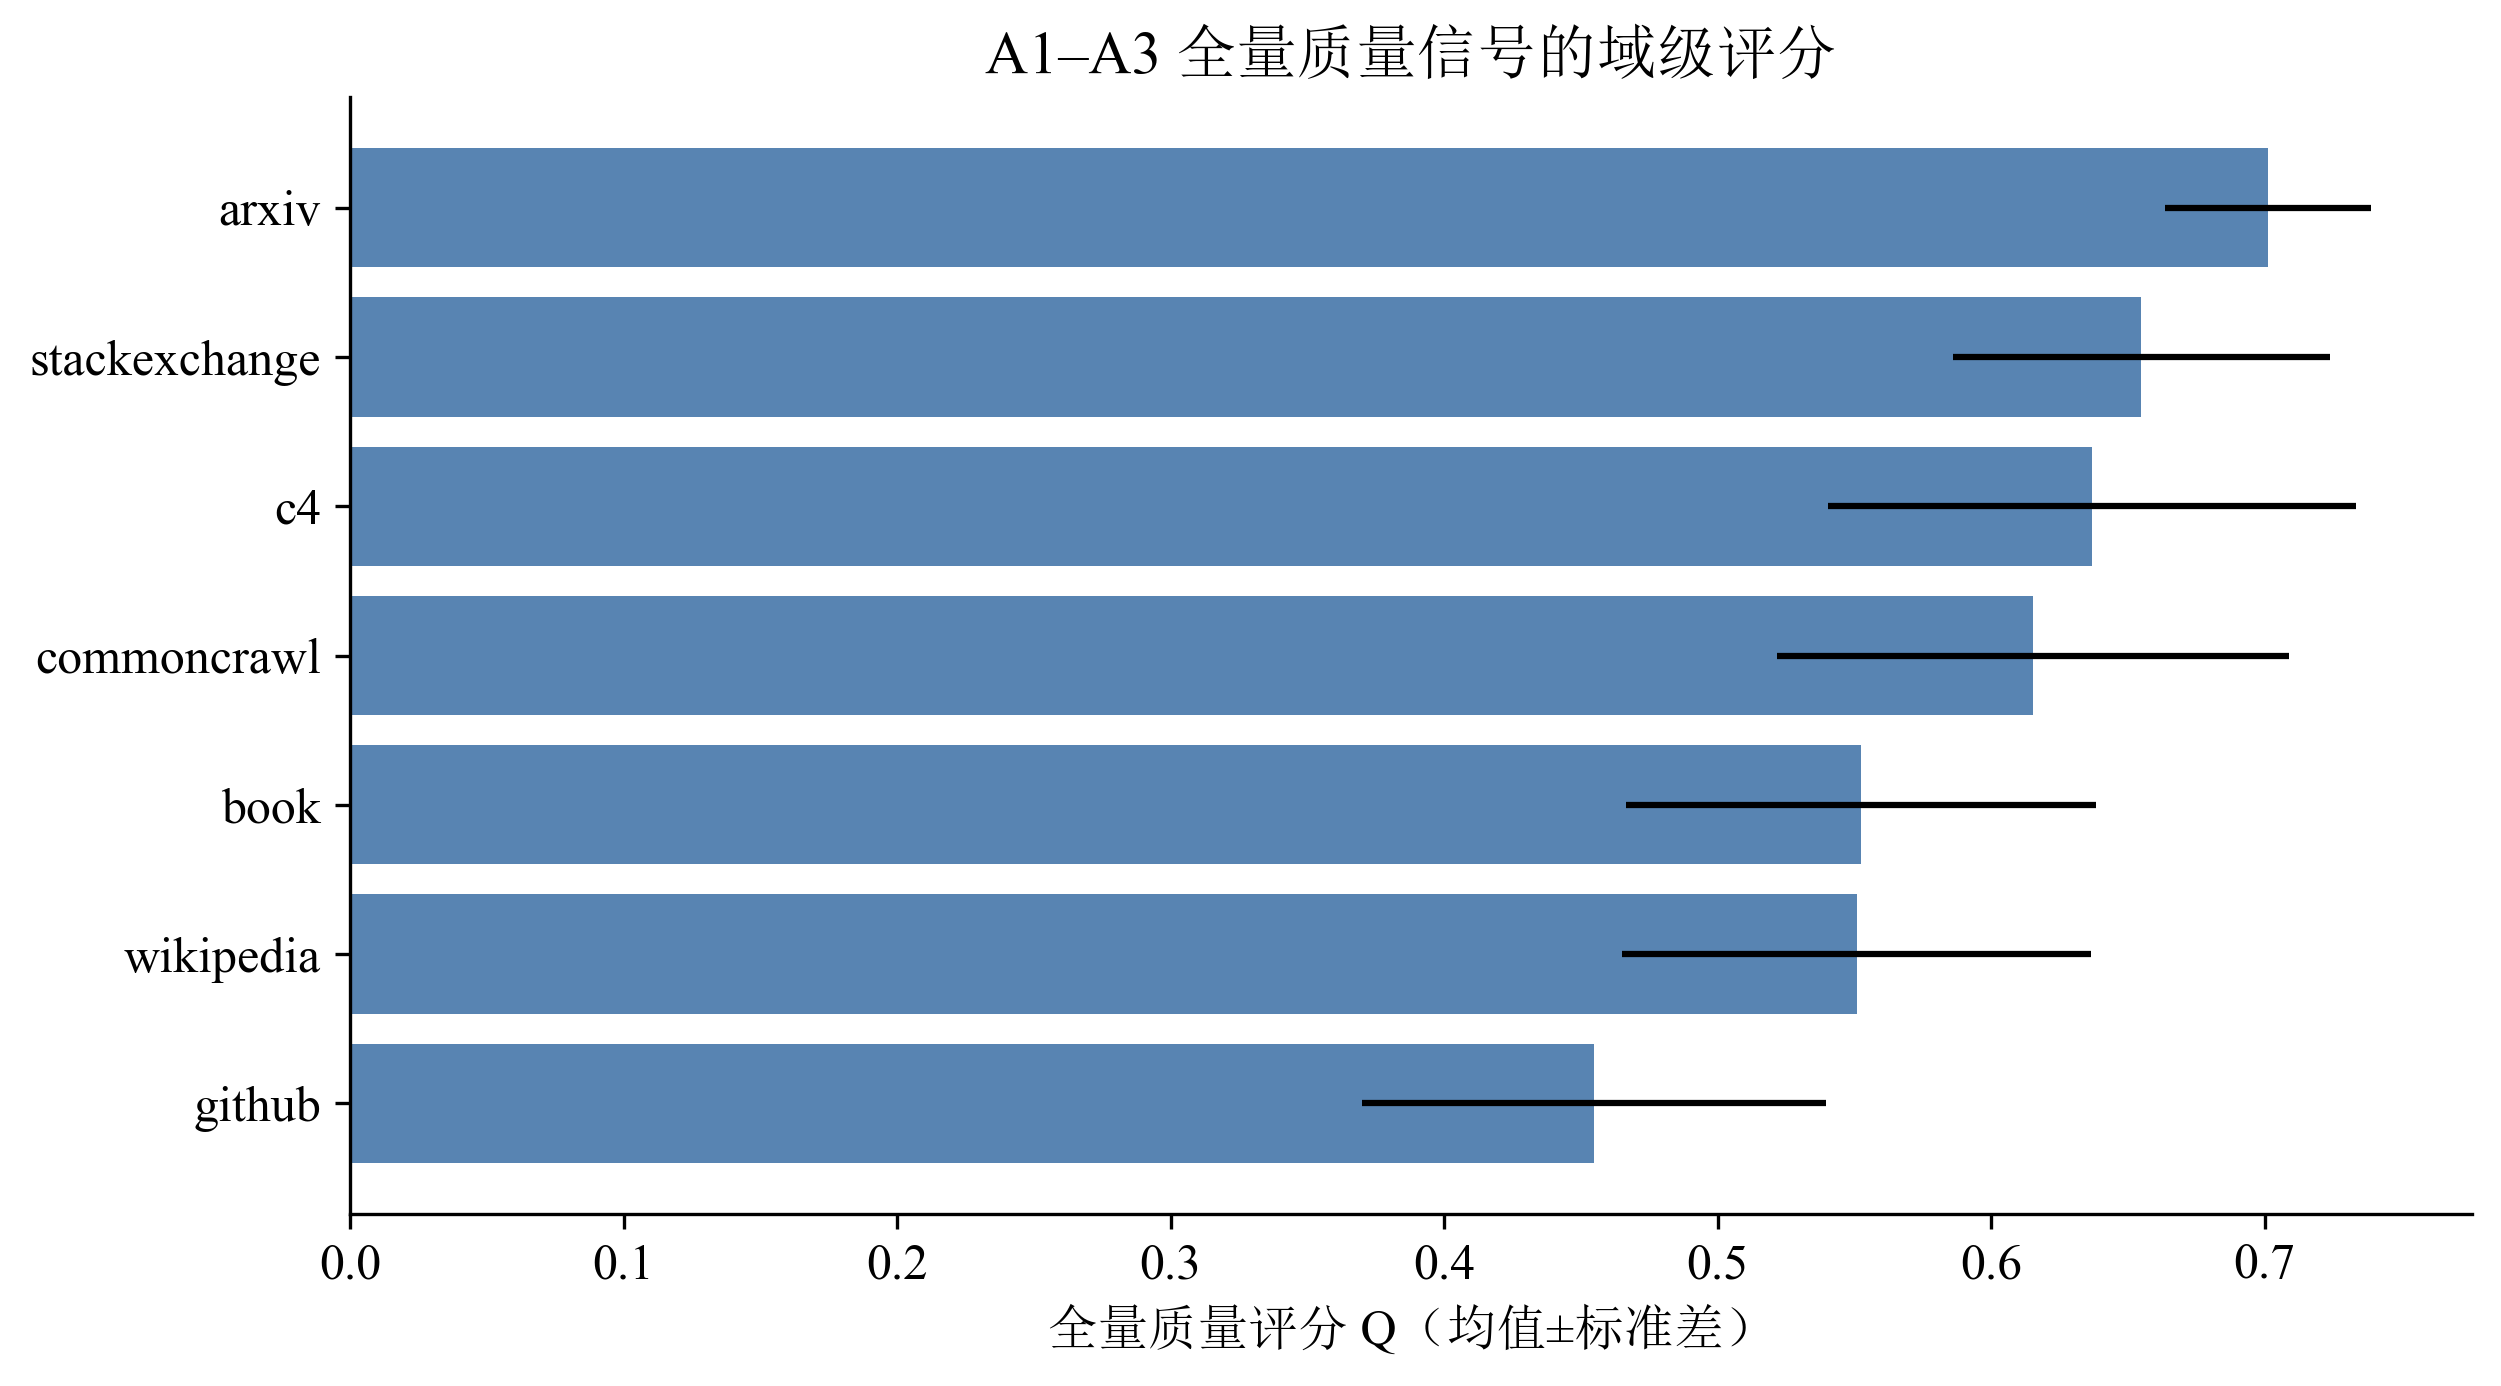

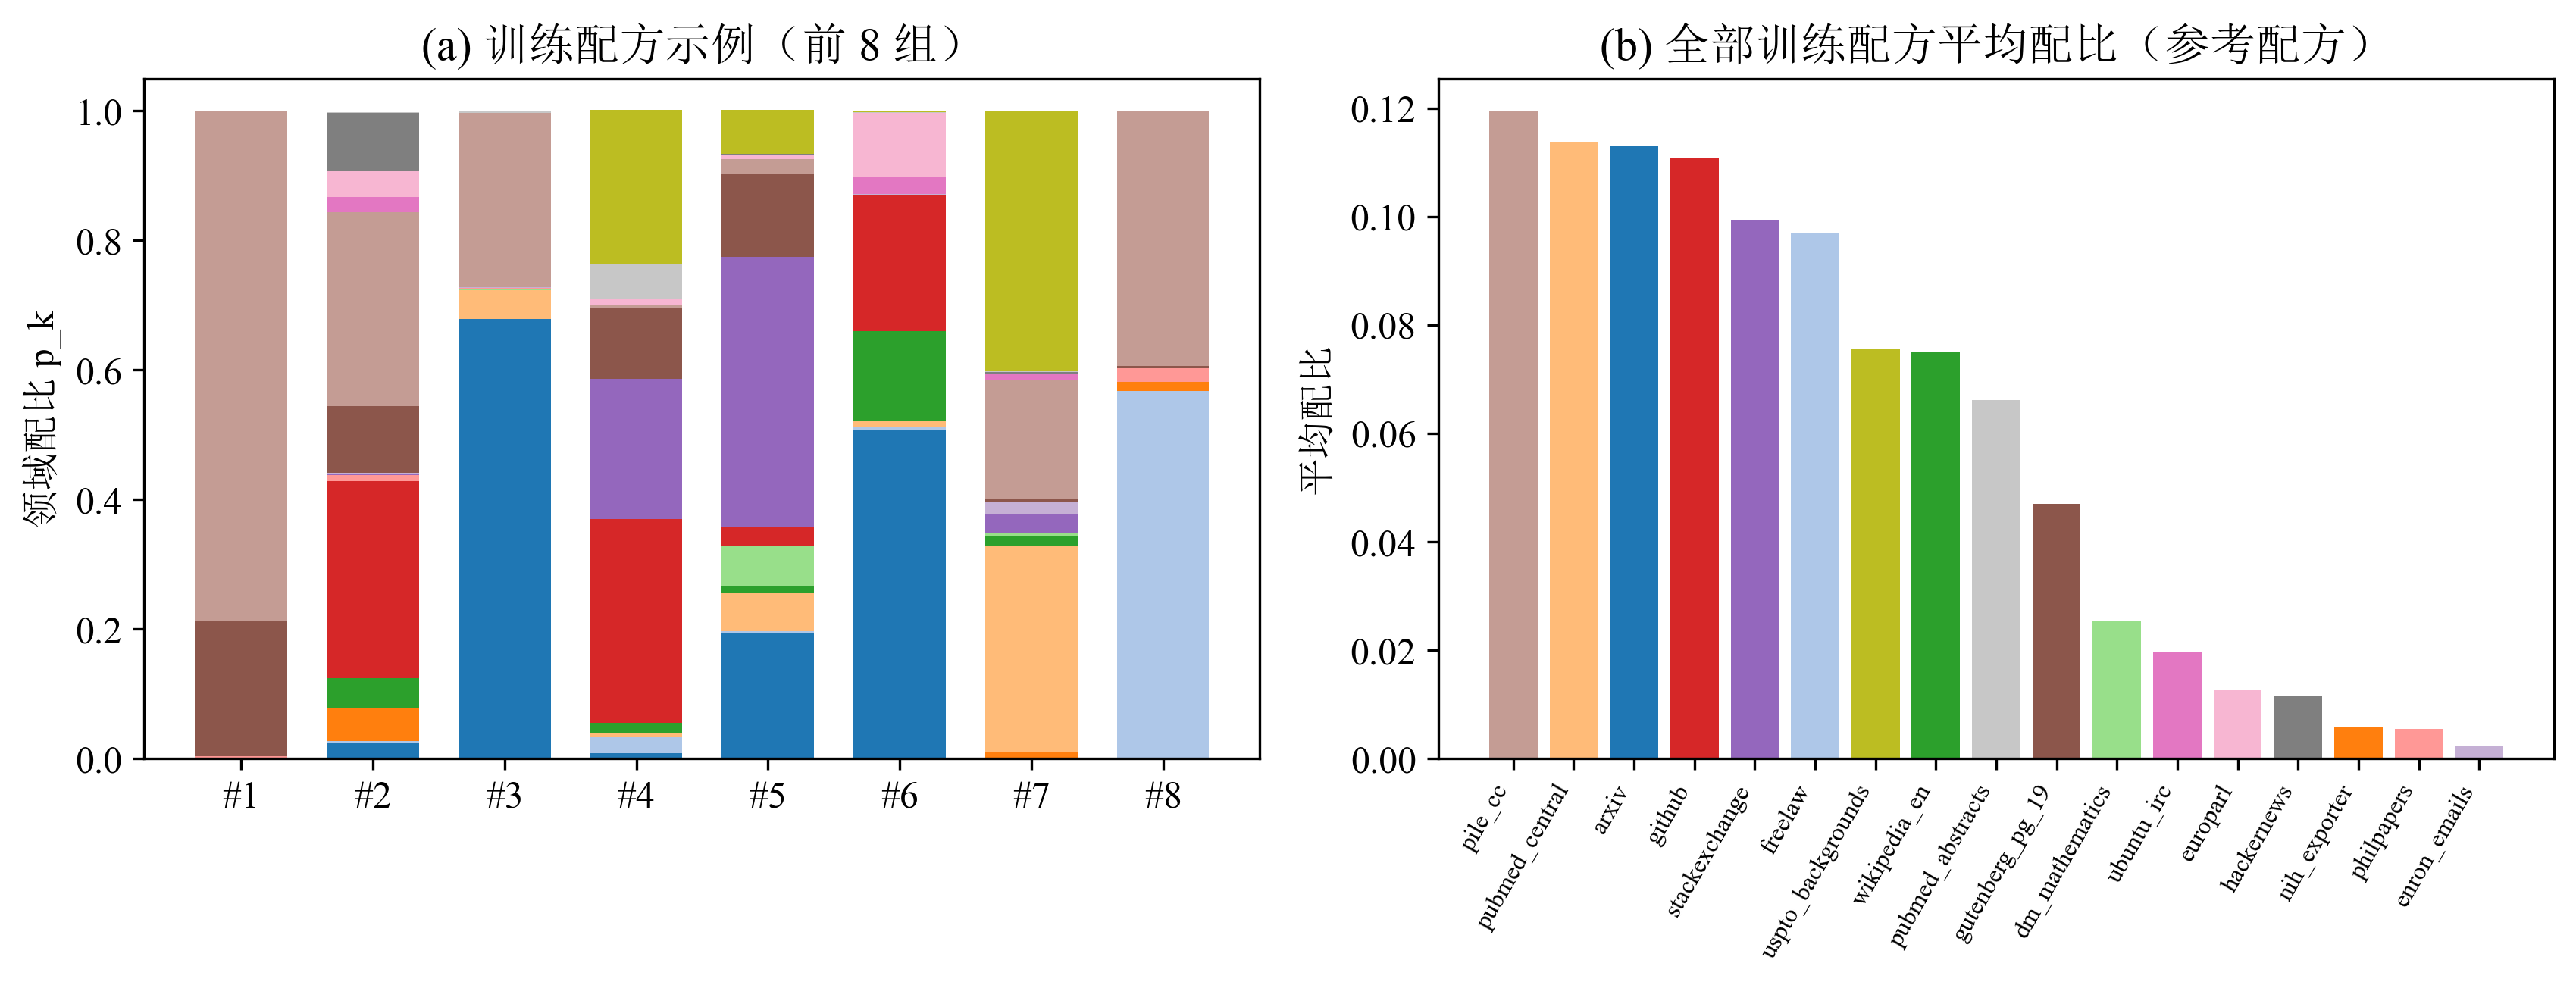

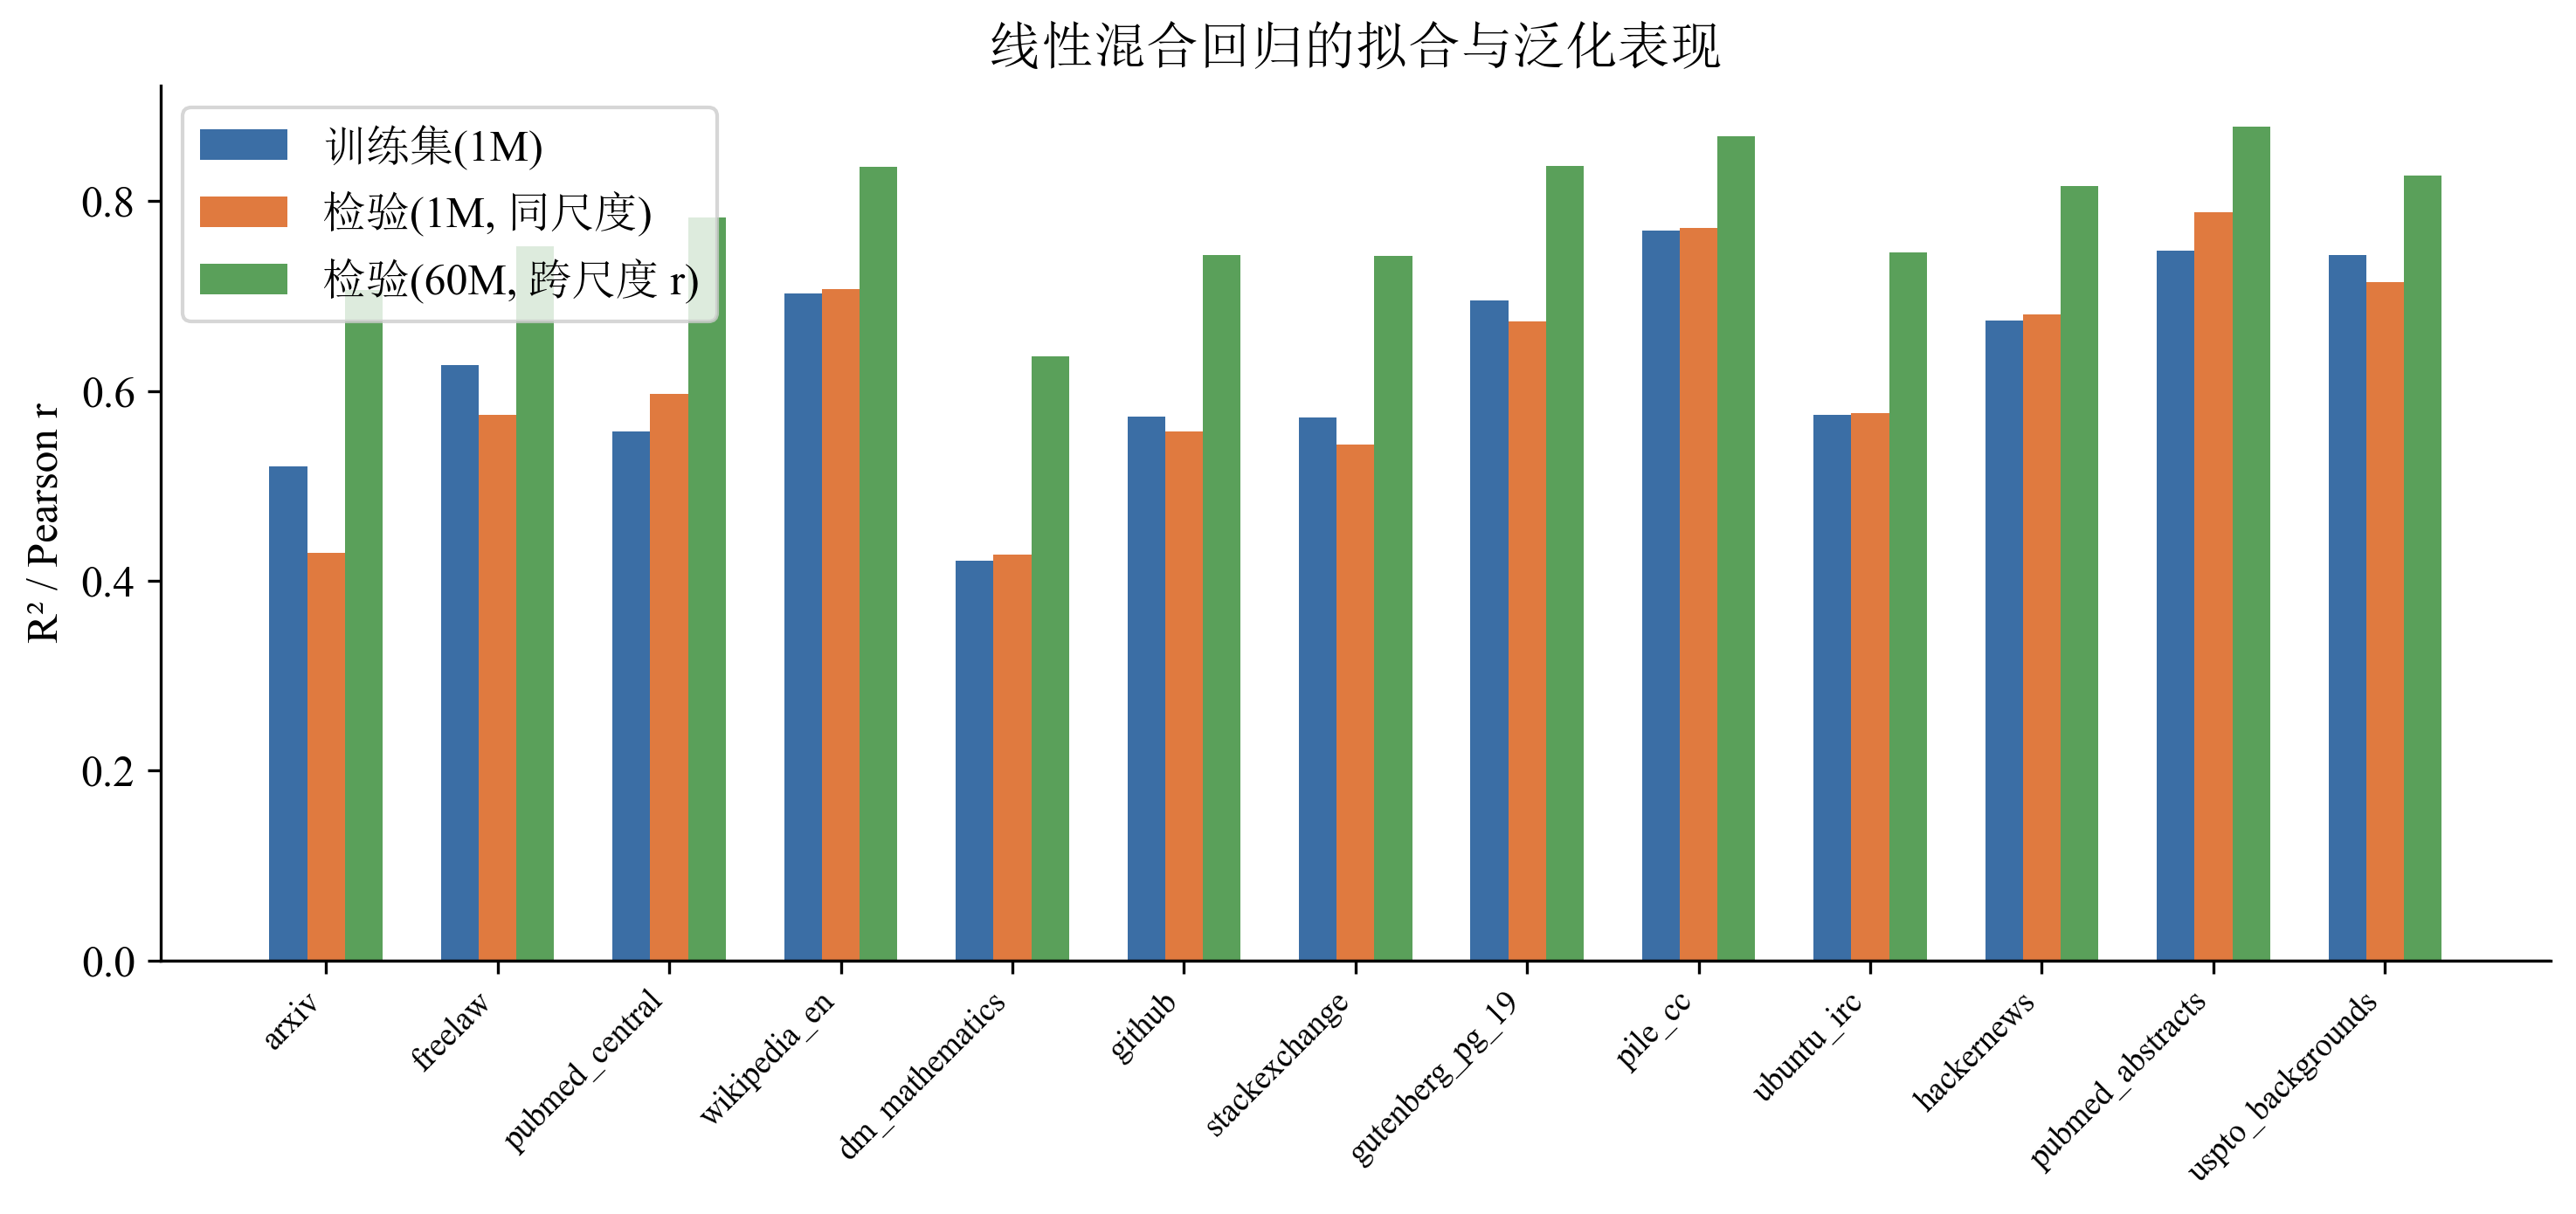

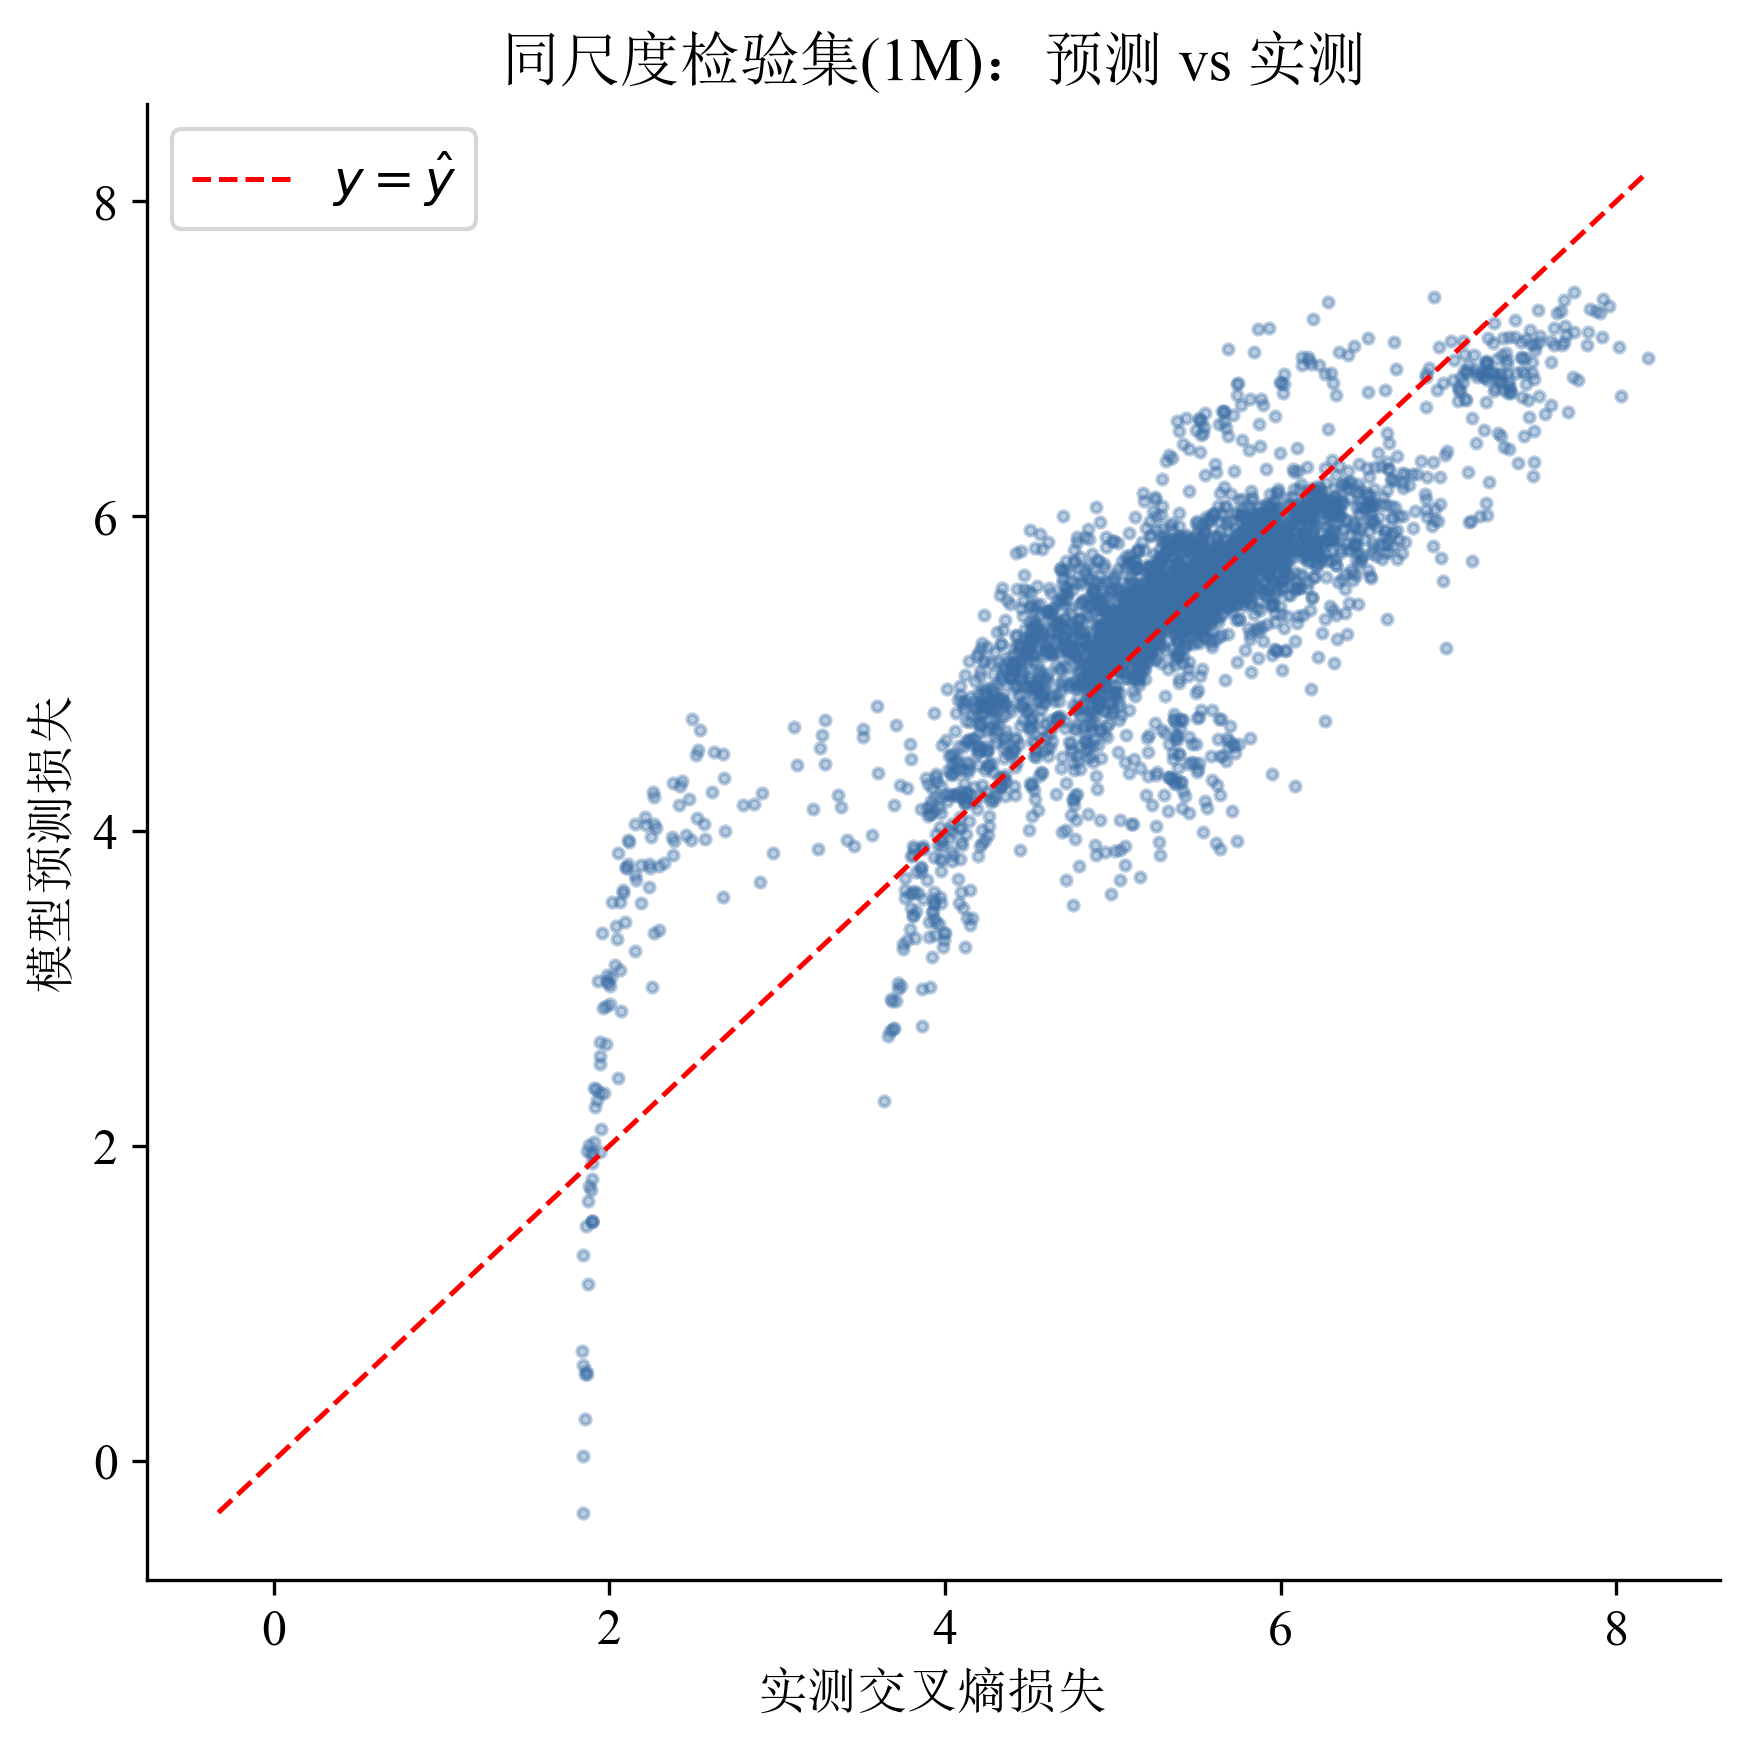

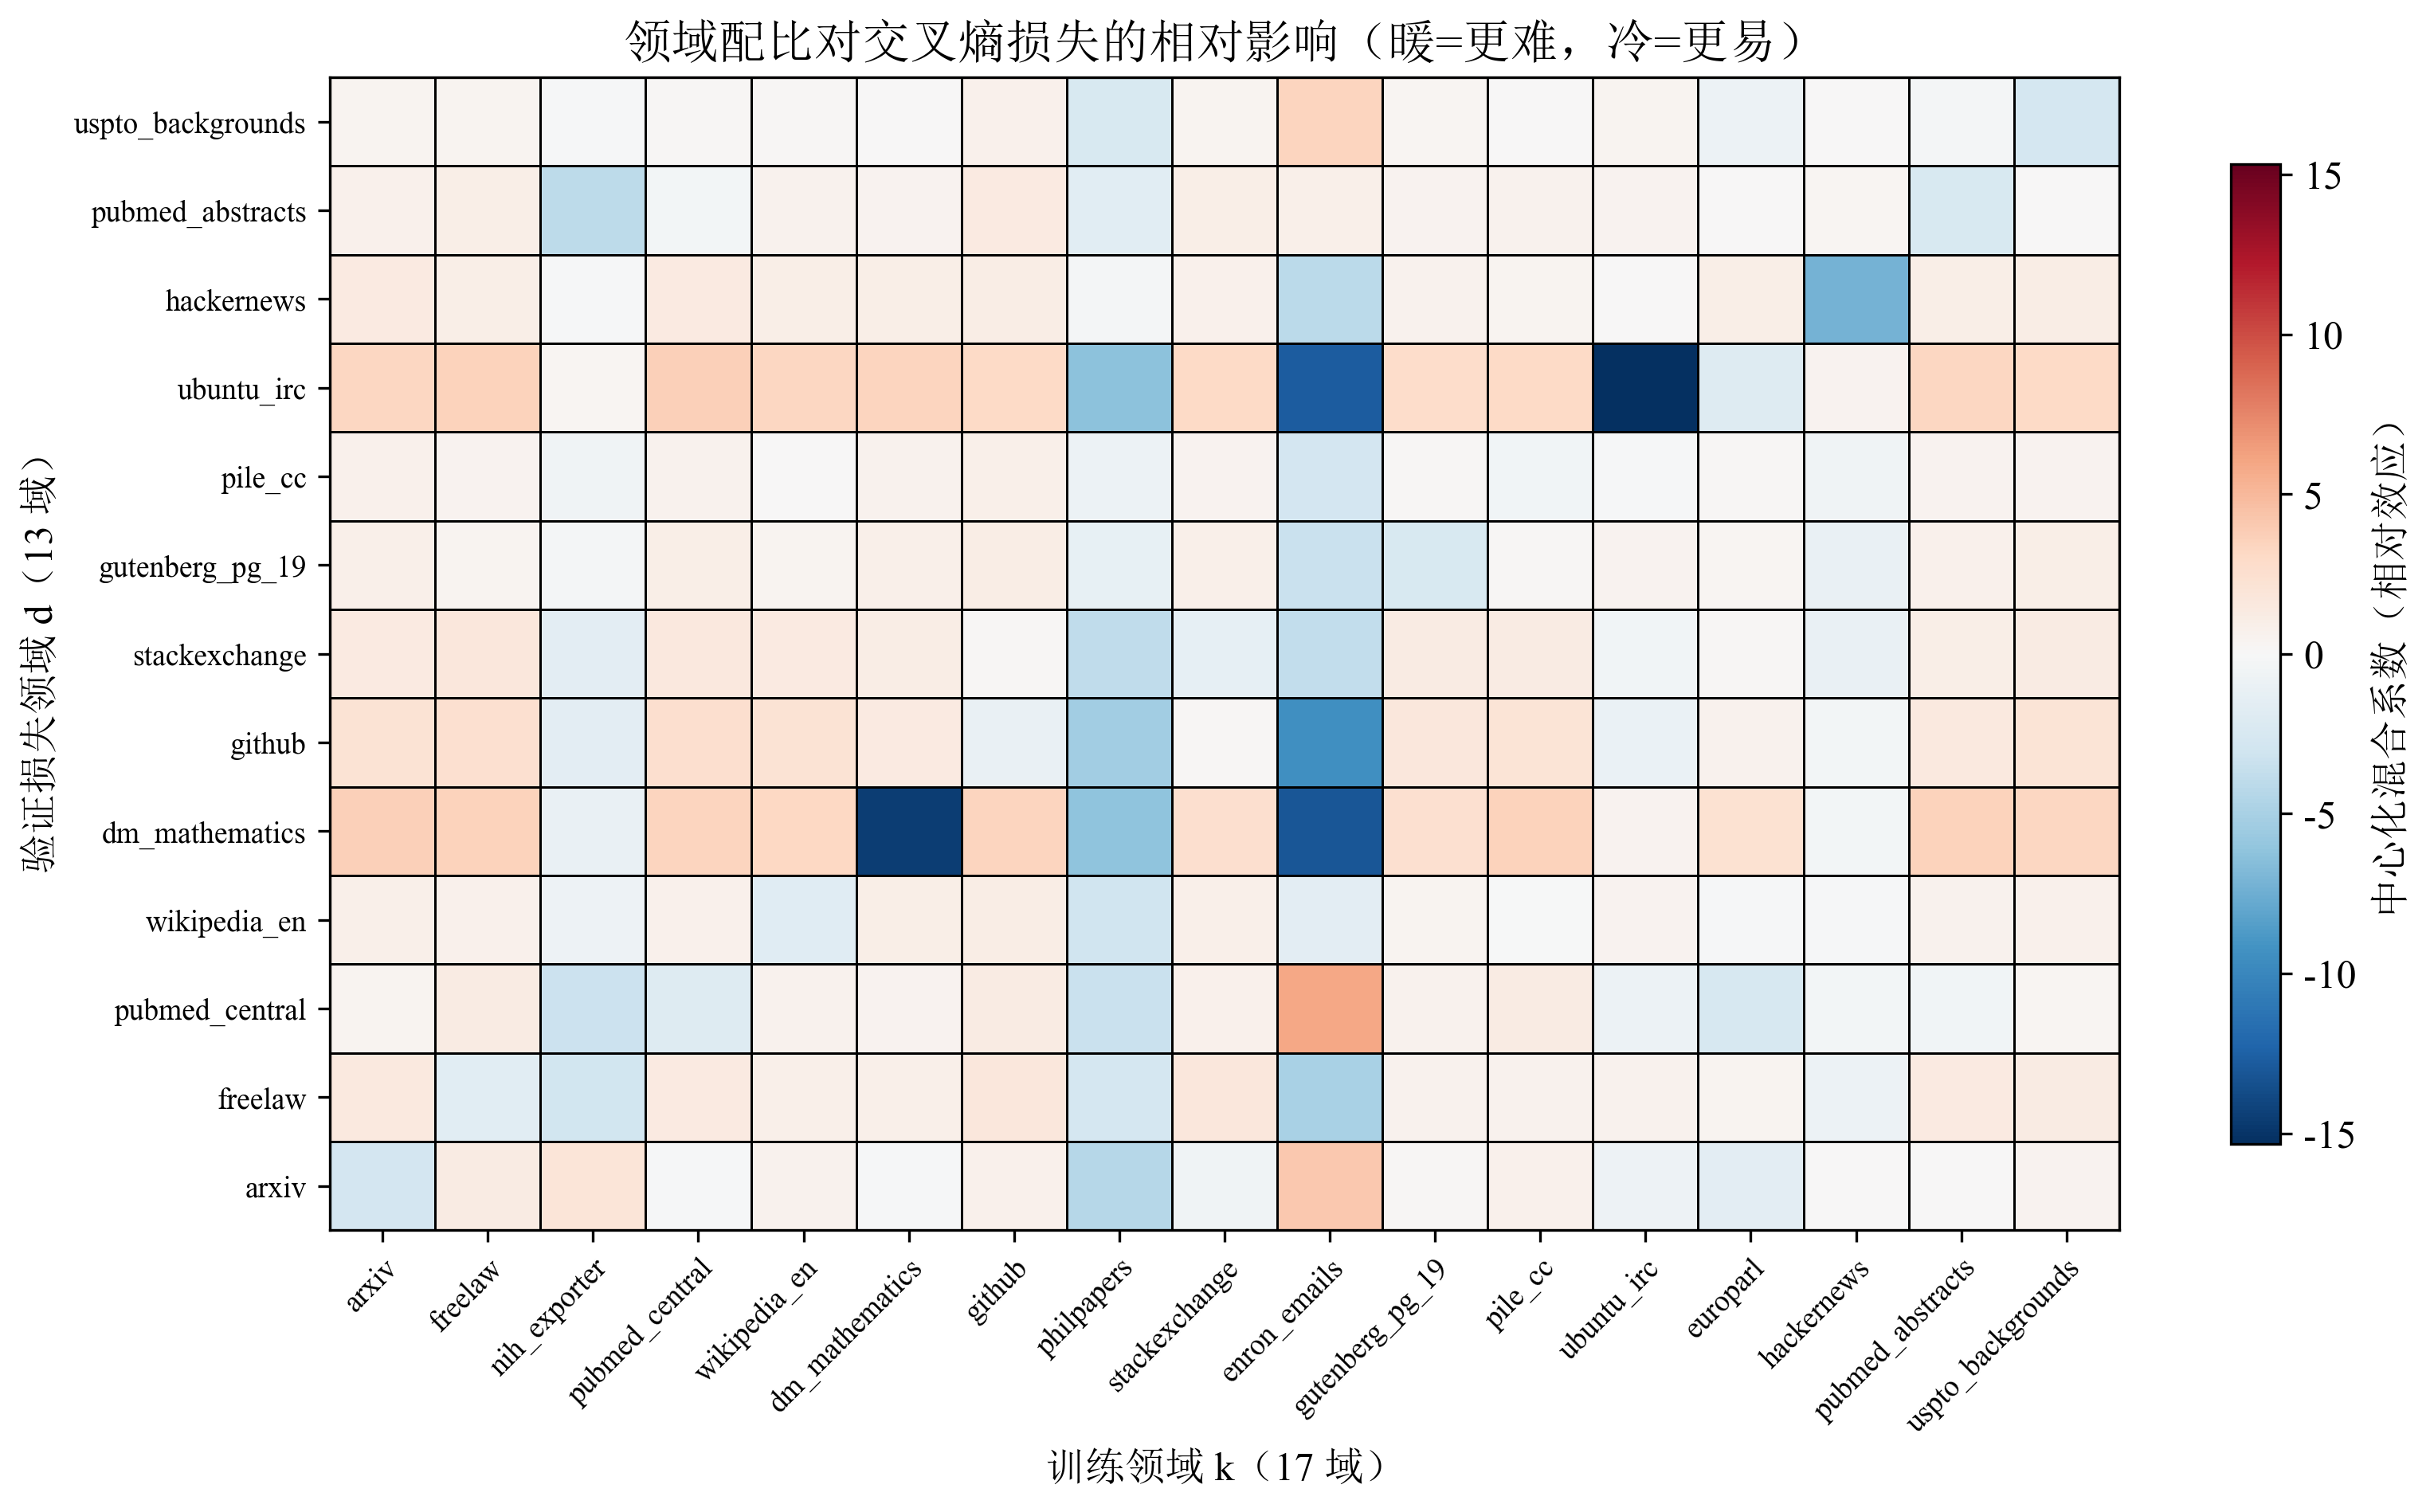

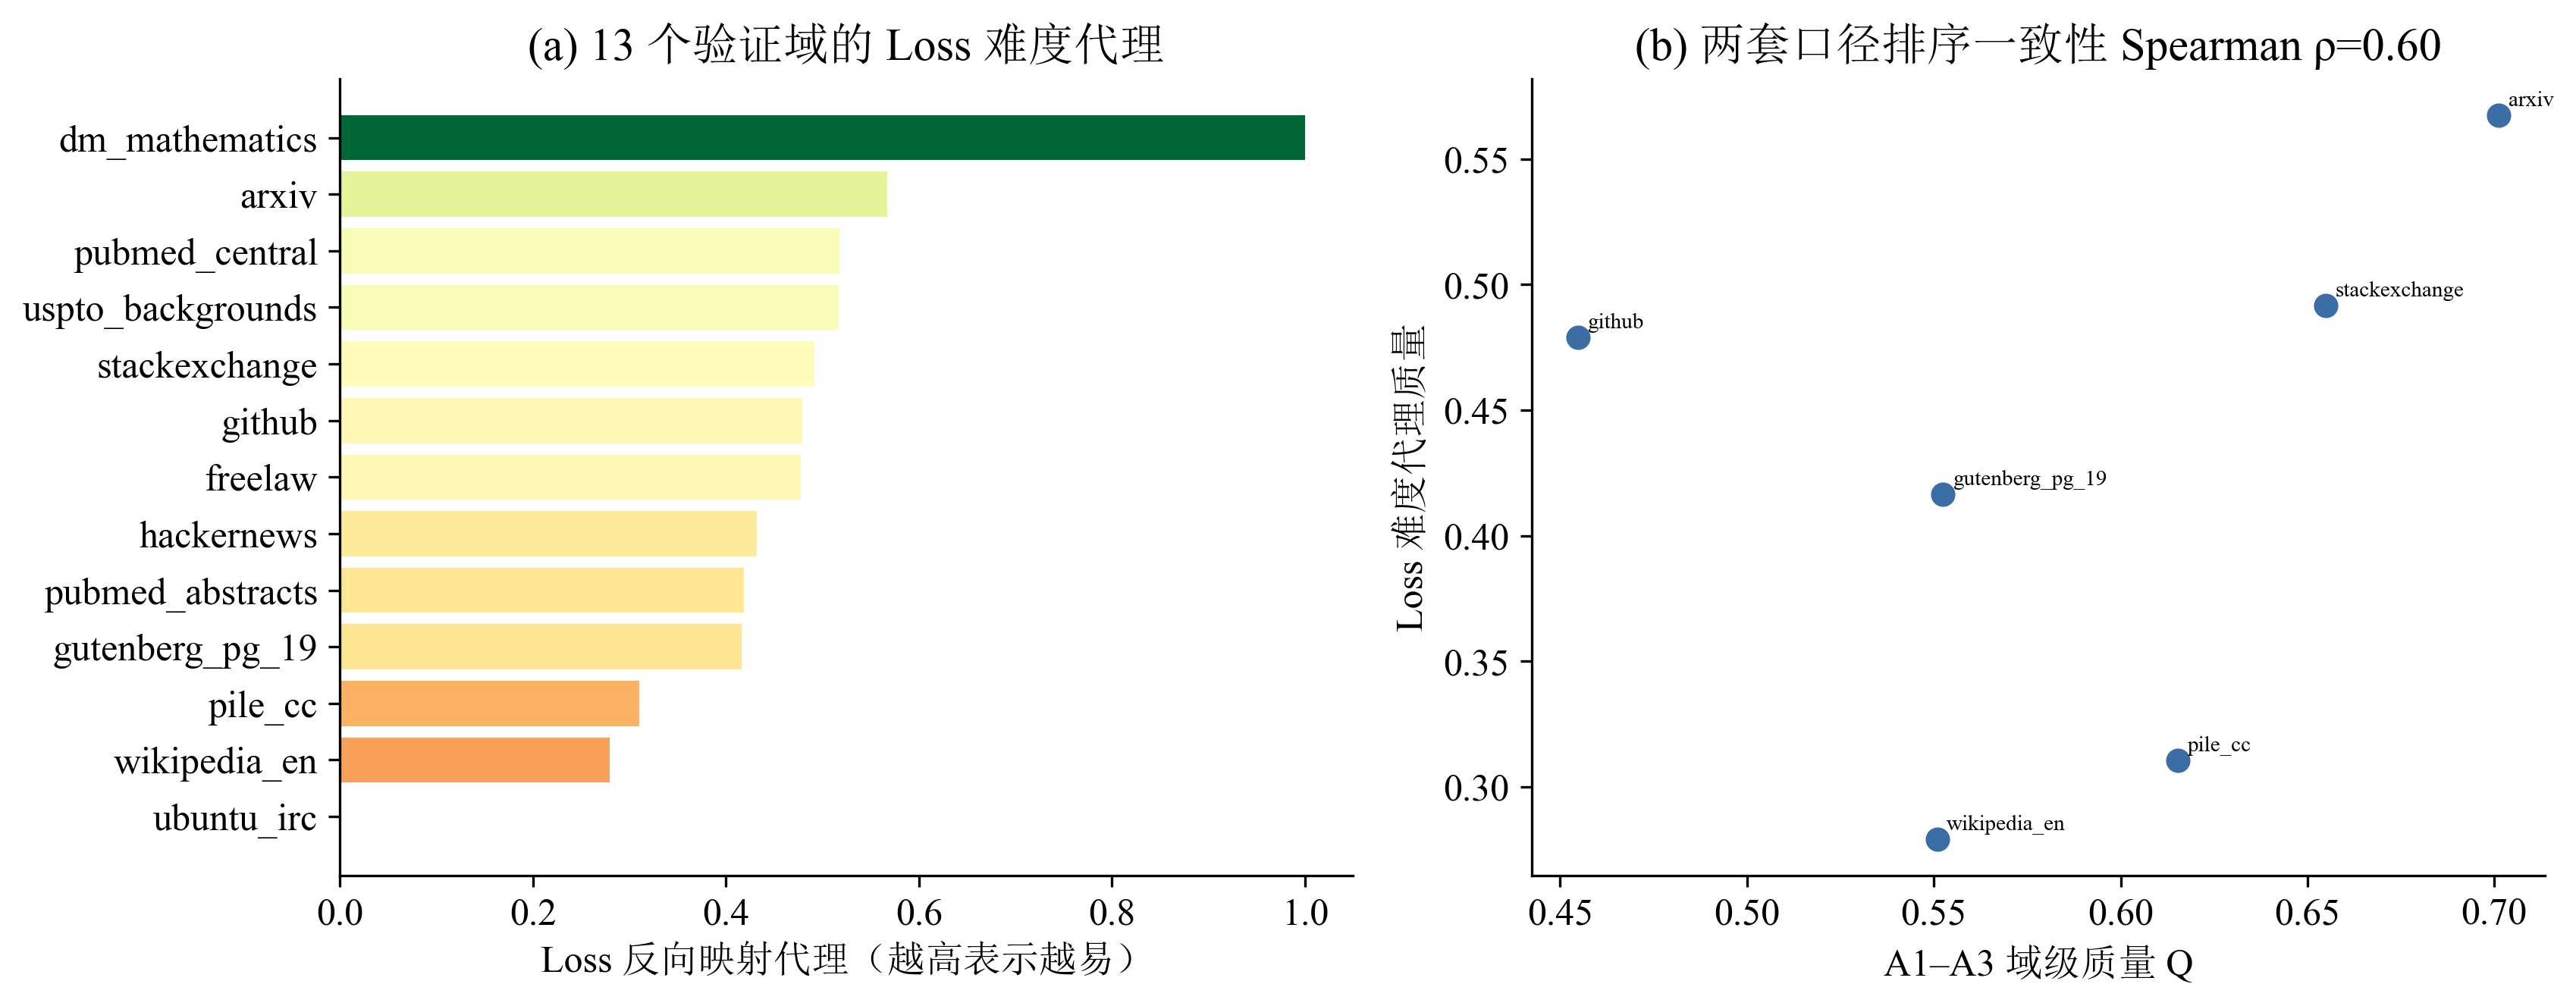

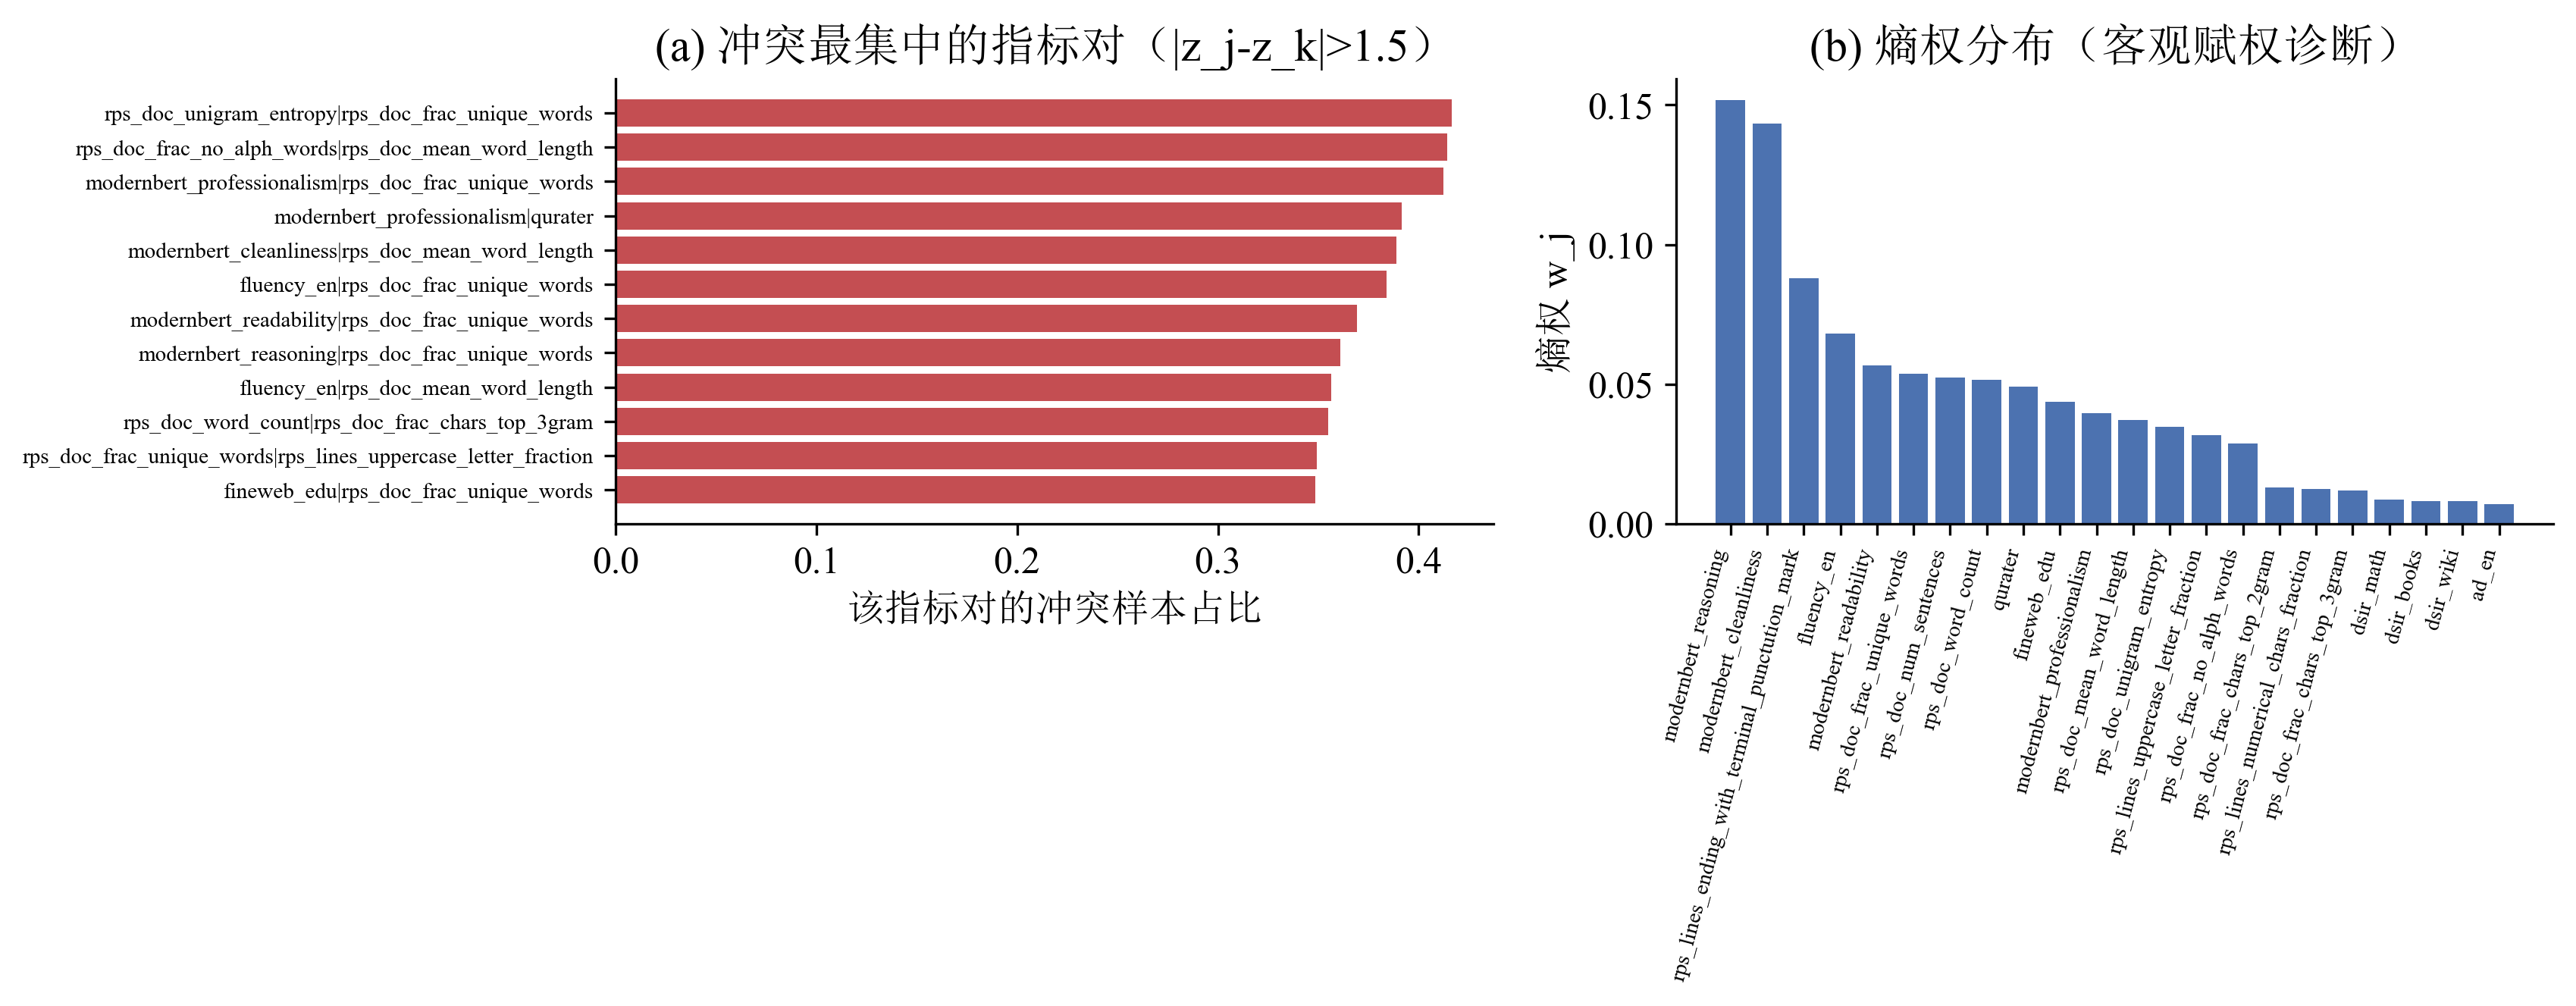

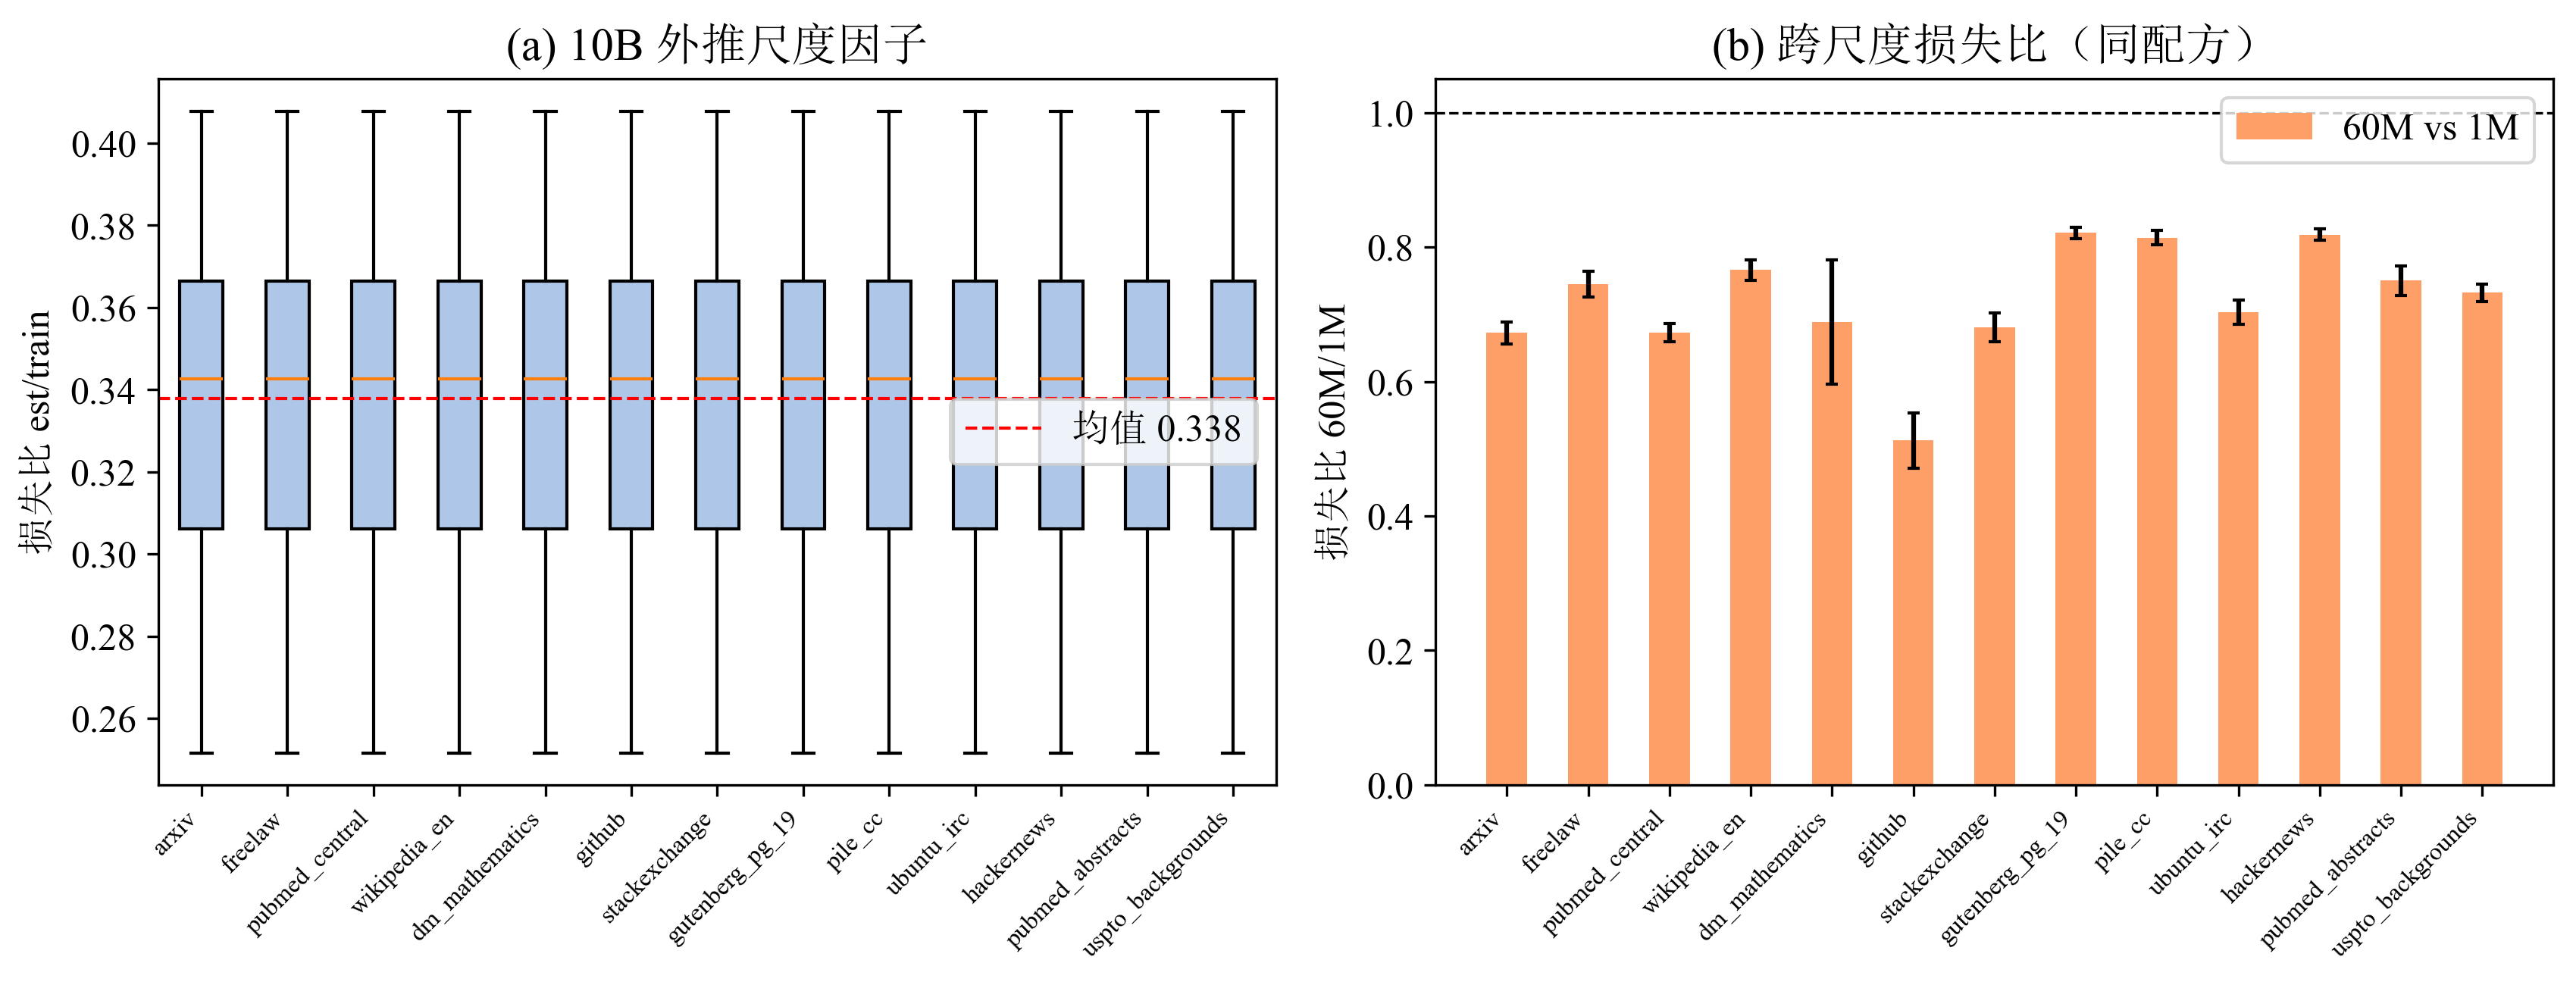

In [10]:
# ============ 7. 绘图 ============
plt.rcParams['font.size'] = 12
cmap = safe_cmap('tab20')
colors = [cmap(i % 20) for i in range(17)]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.barh(quality_domain['domain'], quality_domain['quality_mean'],
        xerr=quality_domain['quality_std'], color='#3b6ea5', alpha=0.85)
ax.set_xlabel('全量质量评分 Q（均值±标准差）')
ax.set_title('A1–A3 全量质量信号的域级评分')
despine(ax); fig.tight_layout(); save_fig(fig, '图0_A1-A3全量质量评分')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
ax = axes[0]
for r in range(8):
    bottom = 0
    for k in range(17):
        ax.bar(r, Xtr[r, k], bottom=bottom, color=colors[k], width=0.7)
        bottom += Xtr[r, k]
ax.set_xticks(range(8)); ax.set_xticklabels(['#%d' % (r + 1) for r in range(8)])
ax.set_ylabel('领域配比 p_k'); ax.set_title('(a) 训练配方示例（前 8 组）'); ax.set_ylim(0, 1.05)
ax = axes[1]
order = np.argsort(-ref)
ax.bar(range(17), ref[order], color=[colors[k] for k in order])
ax.set_xticks(range(17)); ax.set_xticklabels([DOMAINS[k] for k in order],
                                             rotation=60, ha='right', fontsize=8)
ax.set_ylabel('平均配比'); ax.set_title('(b) 全部训练配方平均配比（参考配方）')
fig.tight_layout(); save_fig(fig, '图1_训练配比结构')

fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(13); w = 0.22
ax.bar(x - w, r2_tr, w, label='训练集(1M)', color='#3b6ea5')
ax.bar(x, r2_te1, w, label='检验(1M, 同尺度)', color='#e07a3f')
ax.bar(x + w, r_te2, w, label='检验(60M, 跨尺度 r)', color='#5aa05a')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(LOSS_DOMAINS, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('R² / Pearson r'); ax.set_title('线性混合回归的拟合与泛化表现')
ax.legend(); despine(ax); fig.tight_layout(); save_fig(fig, '图2_线性模型R2')

fig, ax = plt.subplots(figsize=(6, 6))
Yh = predict(Xte1, A, b)
all_y, all_h = Yte1.ravel(), Yh.ravel()
lo, hi = min(all_y.min(), all_h.min()), max(all_y.max(), all_h.max())
ax.scatter(all_y, all_h, s=6, alpha=0.35, color='#3b6ea5')
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.2, label='$y=\\hat y$')
ax.set_xlabel('实测交叉熵损失'); ax.set_ylabel('模型预测损失')
ax.set_title('同尺度检验集(1M)：预测 vs 实测')
ax.legend(); despine(ax); fig.tight_layout(); save_fig(fig, '图3_预测vs实测')

fig, ax = plt.subplots(figsize=(11, 6.5))
mesh = safe_heatmap(ax, A_cent.T, row_labels=LOSS_DOMAINS, col_labels=DOMAINS,
                    cmap='RdBu_r', fontsize=9)
vmax = np.abs(A_cent).max()
mesh.set_clim(-vmax, vmax)
cb = fig.colorbar(mesh, ax=ax, shrink=0.85)
cb.set_label('中心化混合系数（相对效应）')
ax.set_xlabel('训练领域 k（17 域）'); ax.set_ylabel('验证损失领域 d（13 域）')
ax.set_title('领域配比对交叉熵损失的相对影响（暖=更难，冷=更易）')
fig.tight_layout(); save_fig(fig, '图4_混合系数热力图')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
ax = axes[0]
qs = q_df.sort_values('quality_score_Q(loss代理)')
ax.barh(qs['domain'], qs['quality_score_Q(loss代理)'],
        color=plt.colormaps['RdYlGn'](qs['quality_score_Q(loss代理)'].values))
ax.set_xlabel('Loss 反向映射代理（越高表示越易）')
ax.set_title('(a) 13 个验证域的 Loss 难度代理')
despine(ax)
ax = axes[1]
ax.scatter(link.Q_A1A3, link.Q_loss代理, s=45, color='#3b6ea5')
for _, r in link.iterrows():
    ax.annotate(r.mixture_domain, (r.Q_A1A3, r.Q_loss代理), fontsize=7,
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('A1–A3 域级质量 Q'); ax.set_ylabel('Loss 难度代理质量')
ax.set_title('(b) 两套口径排序一致性 Spearman ρ=%.2f' % rho_link)
despine(ax); fig.tight_layout(); save_fig(fig, '图5_领域质量评分')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
ax = axes[0]
tp = quality_pairs['全量'].sort_values(ascending=False).head(12)[::-1]
ax.barh(range(len(tp)), tp.values, color='#c44e52')
ax.set_yticks(range(len(tp))); ax.set_yticklabels(tp.index, fontsize=7)
ax.set_xlabel('该指标对的冲突样本占比')
ax.set_title('(a) 冲突最集中的指标对（|z_j-z_k|>%.1f）' % CONFLICT_TAU)
despine(ax)
ax = axes[1]
wi = np.argsort(quality_weights)[::-1]
ax.bar(range(22), quality_weights[wi], color='#4c72b0')
ax.set_xticks(range(22)); ax.set_xticklabels([QUALITY_COLS[k] for k in wi],
                                             rotation=75, ha='right', fontsize=7)
ax.set_ylabel('熵权 w_j'); ax.set_title('(b) 熵权分布（客观赋权诊断）')
despine(ax); fig.tight_layout(); save_fig(fig, '图6_冲突与赋权诊断')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
ax = axes[0]
bp = safe_boxplot(ax, [ratio10[:, j] for j in range(13)], LOSS_DOMAINS)
for box in bp['boxes']:
    box.set_facecolor('#aec7e8')
ax.set_xticklabels(LOSS_DOMAINS, rotation=45, ha='right', fontsize=8)
ax.axhline(ratio10.mean(), color='r', ls='--', lw=1, label='均值 %.3f' % ratio10.mean())
ax.set_ylabel('损失比 est/train'); ax.set_title('(a) 10B 外推尺度因子'); ax.legend()
ax = axes[1]
x = np.arange(13)
ax.bar(x, ratio_scale.mean(axis=0), 0.5, yerr=ratio_scale.std(axis=0),
       color='#ff9f68', capsize=2, label='60M vs 1M')
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(LOSS_DOMAINS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('损失比 60M/1M'); ax.set_title('(b) 跨尺度损失比（同配方）'); ax.legend()
fig.tight_layout(); save_fig(fig, '图7_外推与跨尺度')


## 第 8 步：汇总与跨问接口

输出 `问题一_关键量.json`（拟合/检验精度、冲突率、全局平均质量 $Q_0$、$\bar Q$ 的 $R^2$ 增量等）。其中 $Q_0$ 会被问题三直接读取作为**基线质量**——这是四问递进耦合的第一个接口。

In [11]:
# ============ 8. 汇总 ============
save_csv_safe(pd.DataFrame({'loss_domain': LOSS_DOMAINS, 'train_R2': r2_tr, 'test1m_R2': r2_te1,
                            'test60m_r': r_te2, 'test1B_r': r_te3, 'mean_loss': diff_mean,
                            'quality_Q(loss代理)': quality_proxy}), '问题一_拟合汇总.csv')

conf = pd.read_csv(os.path.join(OUT_DIR, '质量冲突与一致性.csv'))
meta_out = {
    'train_mean_R2': float(r2_tr.mean()), 'test1m_mean_R2': float(r2_te1.mean()),
    'test60m_mean_r': float(r_te2.mean()), 'test1B_mean_r': float(r_te3.mean()),
    'n_quality_records': int(len(quality_meta)),
    'n_A1': int((quality_meta.source == 'A1').sum()),
    'n_ext': int((quality_meta.source != 'A1').sum()),
    'Q0_global_mean': float(quality_meta.quality_Q.mean()),
    'Q0_mix_weighted': float(ref @ qvec),
    'kendall_W_full': float(conf.loc[conf.dataset.eq('全量'), 'kendall_W'].iloc[0]),
    'conflict_rate_full': float(conf.loc[conf.dataset.eq('全量'), 'conflict_rate'].iloc[0]),
    'conflict_indep_baseline': float(conf.loc[conf.dataset.eq('全量'), 'indep_baseline'].iloc[0]),
    'spearman_quality_vs_lossproxy': float(rho_link),
    'Qbar_R2_gain_mean': float((r2_z - r2_tr).mean()),
}
with open(shared_path('问题一_关键量.json'), 'w', encoding='utf-8') as fh:
    json.dump(meta_out, fh, ensure_ascii=False, indent=2)

print('\n===== 问题一求解完成 =====')
print('训练平均 R2=%.4f; 同尺度检验 R2=%.4f; 跨尺度相关 60M=%.4f, 1B=%.4f'
      % (r2_tr.mean(), r2_te1.mean(), r_te2.mean(), r_te3.mean()))
print('追加混合质量指数 Qbar 的平均 R2 增量 = %.5f' % (r2_z - r2_tr).mean())
print('全局平均质量 Q0 = %.4f（供问题三基线使用）' % quality_meta.quality_Q.mean())
if RC_FAILS:
    print('注意：以下结果文件因被占用而改存：', RC_FAILS)



===== 问题一求解完成 =====
训练平均 R2=0.6290; 同尺度检验 R2=0.6186; 跨尺度相关 60M=0.7824, 1B=0.6515
追加混合质量指数 Qbar 的平均 R2 增量 = 0.00010
全局平均质量 Q0 = 0.4952（供问题三基线使用）


## 结论解读与本问小结

请对照上方输出阅读以下几点（这些是本题的评分要点）：

1. **Kendall $W=0.063$、冲突率 22.3%，低于"指标独立"基准 28.9%**。因此正确的表述是"指标之间存在正相关，但一致性并不强、冲突确实存在"，**不能**说成"各指标高度一致、不存在矛盾"。冲突成因可归为三类：度量对象不同（如熵与唯一词占比同测多样性）、内容类型差异、分布形态差异。
2. **抽样集 A1 与扩展集 A2/A3 的域级质量高度吻合**（arxiv 0.4437 对 0.4430，github 0.2967 对 0.2958，差异 $<0.001$），说明评分口径可跨集合迁移。
3. **配比—损失岭回归**：训练平均 $R^2=0.629$、同尺度检验 $0.619$（无明显过拟合），60M/1B 跨尺度 Pearson 相关 $0.782/0.651$，10B/70B 外推尺度因子稳定（均值 0.338 / 0.266），说明该关系可跨尺度复用。
4. **质量是否进配比模型**：追加混合质量指数 $\bar Q$ 后平均 $R^2$ 只提升 $5\times10^{-5}$ —— 说明线性配比已经吸收了质量信息，因此**不应**再把它作为配比模型的解释变量，而应作为独立资源交给问题二、三。
5. **有界推荐配比**显著提高 pubmed_central、stackexchange、pubmed_abstracts 等学术域，压缩 pile_cc、arxiv、github 等域，预测加权平均损失由 5.336 降至 5.136。

**一个必须说清的区分**：A1–A3 的文本质量 $Q$ 与"损失难度代理" $Q^{(\text{loss})}$ 在 6 个可映射域上的排序相关只有 0.20 —— "文本质量高"和"该域损失低"不是一回事（损失高的域可能恰是高质量但难拟合的领域）。因此质量评分要按用途区分使用。